# dcrypt-region marker informativeness

Train GIN models and quantify which fate markers are informative for curvature prediction inside dcrypt-defined regions. The analysis includes region-wise baseline performance, marker-removal ablations, local receptive-field marker counts, a crypt-only comparison between crypt domains with/without LGR5, and whole-organoid marker-removal contexts for LGR5, Lysozyme+Agr2, and Serotonin+Chroma.


**Setup**

Import shared libraries and define paths relative to the project root.

In [25]:
import copy
import json
import pickle
import sys
from collections import deque
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

Configure the dataset, dcrypt region definitions, model size, training parameters, and analysis budgets. Marker ablation is intentionally run in `single` mode only: one marker-positive cell is removed per perturbation case.

In [ ]:
# Data and target settings
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Optional target residualization against a train-only global-feature baseline
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split settings
VAL_FRAC = 0.3
SPLIT_SEED = None

# dcrypt region settings
DCRYPT_FIELD = "d_crypts_graph"
DCRYPT_REGION_ORDER = [
    "dcrypt_lt_0p8",
    "dcrypt_0p8_to_1p2",
    "dcrypt_gt_1p2",
    "no_crypt",
]
DCRYPT_REGION_LABELS = {
    "dcrypt_lt_0p8": "dcrypt < 0.75",
    "dcrypt_0p8_to_1p2": "0.75 <= dcrypt <= 1.2",
    "dcrypt_gt_1p2": "dcrypt > 1.2",
    "no_crypt": "no crypt",
    "crypt_with_LGR5": "LGR5+ crypt",
    "crypt_without_LGR5": "LGR5- crypt",
}
CRYPT_COMPARISON_ORDER = [
    "crypt_with_LGR5",
    "crypt_without_LGR5",
]
LGR5_MARKER_NAME = "LGR5"

# Marker-removal categories evaluated on the originally LGR5-positive crypt domains.
REMOVAL_SETS = [
    {
        "key": "lgr5_removed",
        "label": "LGR5",
        "markers": ["LGR5"],
    },
    {
        "key": "lysozyme_agr2_removed",
        "label": "Lysozyme+Agr2",
        "markers": ["Lysozyme", "Agr2"],
    },
    {
        "key": "serotonin_chroma_removed",
        "label": "Serotonin+Chroma",
        "markers": ["Serotonin", "Chroma"],
    },
]
CRYPT_MARKER_REMOVAL_COMPARISON_ORDER = ["crypt_with_LGR5"]
for spec in REMOVAL_SETS:
    train_eval_group = f"crypt_with_LGR5_{spec['key']}_removed"
    eval_only_group = f"crypt_with_LGR5_{spec['key']}_eval_removed"
    DCRYPT_REGION_LABELS[train_eval_group] = f"LGR5+ crypt\ntrain/eval {spec['label']} removed"
    DCRYPT_REGION_LABELS[eval_only_group] = f"LGR5+ crypt\nfull model, {spec['label']} removed eval"
    CRYPT_MARKER_REMOVAL_COMPARISON_ORDER.extend([train_eval_group, eval_only_group])

ANALYSIS_GROUP_ORDER = DCRYPT_REGION_ORDER + CRYPT_COMPARISON_ORDER + [
    group for group in CRYPT_MARKER_REMOVAL_COMPARISON_ORDER
    if group not in CRYPT_COMPARISON_ORDER
]
REMOVAL_SET_LABEL = ", ".join(spec["label"] for spec in REMOVAL_SETS)

# Model settings
MODEL_CLASS = "GINCurvature"
NUM_LAYERS = 2
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Ablation and receptive-field analysis settings
ABLATION_MODES = ["single", "all"]
ABLATION_NORMALIZE_BY = "perturbed_cells"
ABLATION_NORMALIZE_BY_BY_MODE = {
    "single": ABLATION_NORMALIZE_BY,
    "all": "cases",
}
MAX_SUBGRAPHS_PER_GROUP = 2000
MIN_GROUP_NODES = 30
PERTURBATION_BATCH_SIZE = 128
LOCAL_COUNT_HOPS = NUM_LAYERS
RANDOM_SEED = 0
RELATIVE_ERROR_EPS = 1e-8

# Experiment output settings
EXPERIMENT_GROUP = "dcrypt_region_marker_informativeness"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"


In [27]:
def save_mpl_figure(fig, name, *, dpi=300):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figure -> {path}")
    return path


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def marker_index(name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if name in marker_names_in:
        return marker_names_in.index(name)
    lower = {str(m).lower(): i for i, m in enumerate(marker_names_in)}
    key = str(name).lower()
    if key not in lower:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names_in}")
    return lower[key]


def spearman_corr(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    xr = pd.Series(x[mask]).rank(method="average").to_numpy(dtype=float)
    yr = pd.Series(y[mask]).rank(method="average").to_numpy(dtype=float)
    if np.std(xr) == 0 or np.std(yr) == 0:
        return np.nan
    return float(np.corrcoef(xr, yr)[0, 1])


def display_table(df, *, columns=None, head=None):
    """Display a notebook-facing table while keeping machine keys in the stored dataframe."""
    out = df.copy()
    out = out.drop(columns=["group"], errors="ignore")
    if columns is not None:
        out = out[[col for col in columns if col in out.columns]]
    if head is not None:
        out = out.head(int(head))
    display(out)


def zero_marker_channel(graphs_in, marker_name, marker_names_in, *, inplace=False):
    """Return graphs where one marker channel has been set to zero."""
    marker_idx = marker_index(marker_name, marker_names_in)
    graphs_out = graphs_in if inplace else [copy.deepcopy(g) for g in graphs_in]
    for g in graphs_out:
        g.x = g.x.clone()
        g.x[:, marker_idx] = 0
    return graphs_out


def zero_marker_channels(graphs_in, marker_names_to_remove, marker_names_in, *, inplace=False):
    """Return graphs where one or more marker channels have been set to zero everywhere."""
    markers_to_remove = list(marker_names_to_remove)
    marker_indices = [marker_index(marker_name, marker_names_in) for marker_name in markers_to_remove]
    graphs_out = graphs_in if inplace else [copy.deepcopy(g) for g in graphs_in]
    n_positive_zeroed_by_marker = {marker_name: 0 for marker_name in markers_to_remove}
    n_nodes = 0
    for g in graphs_out:
        g.x = g.x.clone()
        n_nodes += int(g.x.shape[0])
        for marker_name, marker_idx in zip(markers_to_remove, marker_indices):
            marker_values = g.x[:, marker_idx].detach().cpu().numpy()
            n_positive_zeroed_by_marker[marker_name] += int(np.sum(marker_values > 0.5))
            g.x[:, marker_idx] = 0
    return graphs_out, {
        "markers": markers_to_remove,
        "region": "whole organoid",
        "n_nodes_zeroed": n_nodes,
        "n_positive_nodes_zeroed_by_marker": n_positive_zeroed_by_marker,
    }


**Data Loading**

Load graph data, attach organoid metadata, select the curvature target, and read marker names.

In [28]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)

Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [ ]:
# Optional day3p5 timepoint filter
from src.data.filters import filter_graphs_by_metadata

DAY3P5_TIMEPOINT = "day3p5"

# Default: remove day3p5 graphs if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

# Alternative: keep only day3p5 graphs and filter out all other timepoints.
# Uncomment this block and comment out the default block above if needed.
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     keep_values={DAY3P5_TIMEPOINT},
#     missing="drop",
#     inplace=False,
#     print_summary=True,
# )


**Filtering**

Apply the same blacklist, organoid-quality filters, spherical-organoid rescue logic, and optional target outlier interpolation used in the other experiment notebooks.

In [29]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.metadata import fill_missing_metadata_for_group
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(
        graphs,
        blacklist,
        print_summary=True,
    )
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                243    341    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         288    409    0.704
20251201         day4p5              193    274    0.704
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------

**Global Features**

Create `global_feat` from log-transformed organoid-level metadata when global features are enabled.

In [30]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


Promoted metadata fields to graph tensor attributes.


**Split And Target Transform**

Split organoids into train and validation sets, standardize global features using the training set, and fit the target transform.

In [31]:
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

baseline_residual_transform = None
if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    if not USE_GLOBAL_FEATURES:
        raise ValueError("SUBTRACT_CONSTANT_GLOBAL_BASELINE requires USE_GLOBAL_FEATURES=True.")
    baseline_residual_transform = GlobalBaselineResidualTransform(num_workers=NUM_WORKERS)
    target_transform = ChainedTargetTransform([
        baseline_residual_transform,
        AsinhStandardizeTransform(robust=True),
    ])
    training_target_description = "target residual: true curvature - global-feature baseline"
else:
    target_transform = AsinhStandardizeTransform(robust=True)
    training_target_description = "raw target"

print("Training target:", training_target_description)

target_transform.fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)

Split -> train: 559 | val: 240
Training target: raw target
global_dim = 4
target_transform = asinh_standardize


**Training Setup**

Define the GIN model and training configuration, including the edge smoothness auxiliary loss.

In [32]:
from src.models.baseline import GlobalFeatureMLP
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


**Model Training**

Train one all-marker GIN model. All downstream analyses ask how marker information supports this trained model in different dcrypt regions.

In [33]:
print(f"Training all-marker {MODEL_CLASS} | depth={NUM_LAYERS}")
model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(NUM_LAYERS),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
model, metrics, history = train(model, g_train, g_val, cfg)
training_log = {
    "model_class": MODEL_CLASS,
    "variant": "all_markers",
    "num_layers": int(NUM_LAYERS),
    "metrics": metrics,
    "history": history,
}


def infer_target_dim_from_graphs(graphs_in):
    y = graphs_in[0].y
    return 1 if y.ndim == 1 else int(y.shape[1])


target_dim = infer_target_dim_from_graphs(g_train)
if global_dim < 1:
    raise ValueError("Control models require USE_GLOBAL_FEATURES=True and attached global_feat tensors.")

print(f"Training global-feature baseline MLP | hidden_dim={HIDDEN_DIM}")
global_baseline_model = GlobalFeatureMLP(
    global_dim=global_dim,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    target_dim=target_dim,
)
global_baseline_model, metrics_global_baseline, history_global_baseline = train(
    global_baseline_model,
    g_train,
    g_val,
    cfg,
)
global_baseline_training_log = {
    "model_class": "GlobalFeatureMLP",
    "variant": "global_baseline_no_marker",
    "num_layers": 0,
    "metrics": metrics_global_baseline,
    "history": history_global_baseline,
}

print(f"Training center-marker GIN baseline | depth=0")
gin_depth0_baseline_model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=0,
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
    target_dim=target_dim,
)
gin_depth0_baseline_model, metrics_gin_depth0_baseline, history_gin_depth0_baseline = train(
    gin_depth0_baseline_model,
    g_train,
    g_val,
    cfg,
)
gin_depth0_baseline_training_log = {
    "model_class": "GINCurvature",
    "variant": "depth0_center_marker_global",
    "num_layers": 0,
    "metrics": metrics_gin_depth0_baseline,
    "history": history_gin_depth0_baseline,
}

removal_variant_graphs = {}
removal_models = {}
removal_training_logs = {}

for spec in REMOVAL_SETS:
    key = spec["key"]
    label = spec["label"]
    markers = spec["markers"]
    print(f"Training {MODEL_CLASS} with {label} channels zeroed in whole organoids | depth={NUM_LAYERS}")
    g_train_removed, train_zero_info = zero_marker_channels(
        g_train,
        markers,
        marker_names,
        inplace=False,
    )
    g_val_removed, val_zero_info = zero_marker_channels(
        g_val,
        markers,
        marker_names,
        inplace=False,
    )
    print(f"Train whole-organoid marker zeroing ({label}):", train_zero_info)
    print(f"Val whole-organoid marker zeroing ({label}):", val_zero_info)

    model_removed = GINCurvature(
        n_markers=int(g_train_removed[0].x.size(1)),
        global_dim=infer_global_dim(g_train_removed),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(NUM_LAYERS),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )
    model_removed, metrics_removed, history_removed = train(
        model_removed,
        g_train_removed,
        g_val_removed,
        cfg,
    )
    removal_variant_graphs[key] = {
        "label": label,
        "markers": list(markers),
        "train": g_train_removed,
        "val": g_val_removed,
        "train_zeroing_info": train_zero_info,
        "val_zeroing_info": val_zero_info,
    }
    removal_models[key] = model_removed
    removal_training_logs[key] = {
        "model_class": MODEL_CLASS,
        "variant": f"{key}_whole_organoid",
        "label": label,
        "zeroed_markers": list(markers),
        "zeroing_region": "whole organoid",
        "train_zeroing_info": train_zero_info,
        "val_zeroing_info": val_zero_info,
        "num_layers": int(NUM_LAYERS),
        "metrics": metrics_removed,
        "history": history_removed,
    }

print("Finished training.")


Training all-marker GINCurvature | depth=2
epoch 001 | train loss 0.5341 mae 0.7626 | val loss 0.5293 mae 0.7726
epoch 002 | train loss 0.4808 mae 0.7317 | val loss 0.4946 mae 0.7481
epoch 003 | train loss 0.4566 mae 0.7146 | val loss 0.4818 mae 0.7466
epoch 004 | train loss 0.4386 mae 0.7062 | val loss 0.4458 mae 0.7155
epoch 005 | train loss 0.4292 mae 0.7012 | val loss 0.4345 mae 0.7145
epoch 006 | train loss 0.4217 mae 0.6941 | val loss 0.4462 mae 0.7306
epoch 007 | train loss 0.4189 mae 0.6950 | val loss 0.4204 mae 0.7038
epoch 008 | train loss 0.4126 mae 0.6927 | val loss 0.4187 mae 0.7059
epoch 009 | train loss 0.4072 mae 0.6866 | val loss 0.4219 mae 0.7105
epoch 010 | train loss 0.4031 mae 0.6872 | val loss 0.4114 mae 0.6974
epoch 011 | train loss 0.3986 mae 0.6841 | val loss 0.4047 mae 0.6976
epoch 012 | train loss 0.3942 mae 0.6806 | val loss 0.4079 mae 0.7018
epoch 013 | train loss 0.3925 mae 0.6822 | val loss 0.4145 mae 0.6964
epoch 014 | train loss 0.3901 mae 0.6790 | val 

**Validation Predictions**

Predict curvature and variance on all validation nodes. These arrays are the reference for baseline performance, marker-count correlations, and ablation error changes.

In [34]:
from src.inference.predict import predict_targets


def predict_model_arrays(graphs_in, model_in):
    y_true_i, y_pred_i, log_var_i, _ = predict_targets(
        graphs_in,
        model_in,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )
    y_true_i = select_target_column(y_true_i, TARGET_INDEX_FOR_PLOTS)
    y_pred_i = select_target_column(y_pred_i, TARGET_INDEX_FOR_PLOTS)
    log_var_i = select_target_column(log_var_i, TARGET_INDEX_FOR_PLOTS)
    pred_var_i = np.exp(log_var_i)
    residual_i = y_pred_i - y_true_i
    sqerr_i = residual_i ** 2
    abserr_i = np.abs(residual_i)
    return {
        "y_true": y_true_i,
        "y_pred": y_pred_i,
        "log_var": log_var_i,
        "pred_var": pred_var_i,
        "residual": residual_i,
        "sqerr": sqerr_i,
        "abserr": abserr_i,
    }


def relative_abs_error_to_global_baseline(pred, baseline_pred, *, eps=RELATIVE_ERROR_EPS):
    abs_err = np.abs(np.asarray(pred["y_pred"], dtype=float) - np.asarray(pred["y_true"], dtype=float))
    baseline_abs_pred = np.abs(np.asarray(baseline_pred["y_pred"], dtype=float))
    out = np.full(abs_err.shape, np.nan, dtype=float)
    valid = np.isfinite(abs_err) & np.isfinite(baseline_abs_pred) & (baseline_abs_pred > eps)
    out[valid] = abs_err[valid] / baseline_abs_pred[valid]
    return out


pred_full = predict_model_arrays(g_val, model)
pred_global_baseline = predict_model_arrays(g_val, global_baseline_model)
pred_gin_depth0_baseline = predict_model_arrays(g_val, gin_depth0_baseline_model)

prediction_contexts = {
    "full": pred_full,
}
control_prediction_contexts = {
    "full": {
        "global_baseline": pred_global_baseline,
        "gin_depth0": pred_gin_depth0_baseline,
    },
}
model_contexts = {
    "full": {
        "model": model,
        "graphs": g_val,
        "label_suffix": "full model",
    },
}
MODEL_CONTEXT_BY_GROUP = {}
removal_prediction_summaries = []

for spec in REMOVAL_SETS:
    key = spec["key"]
    label = spec["label"]
    graphs_removed = removal_variant_graphs[key]["val"]

    train_eval_context = f"{key}_train_eval"
    eval_only_context = f"{key}_eval_only"

    pred_train_eval = predict_model_arrays(graphs_removed, removal_models[key])
    pred_eval_only = predict_model_arrays(graphs_removed, model)
    pred_global_removed_eval = predict_model_arrays(graphs_removed, global_baseline_model)
    pred_gin0_removed_eval = predict_model_arrays(graphs_removed, gin_depth0_baseline_model)

    for context_label, pred_ctx in {
        f"{label} removed train/eval model": pred_train_eval,
        f"full model evaluated with {label} removed": pred_eval_only,
        f"global baseline evaluated with {label} removed": pred_global_removed_eval,
        f"GIN depth-0 baseline evaluated with {label} removed": pred_gin0_removed_eval,
    }.items():
        if not np.allclose(pred_full["y_true"], pred_ctx["y_true"], equal_nan=True):
            raise RuntimeError(f"Validation truth differs between full and {context_label} contexts.")

    prediction_contexts[train_eval_context] = pred_train_eval
    prediction_contexts[eval_only_context] = pred_eval_only
    control_prediction_contexts[train_eval_context] = {
        "global_baseline": pred_global_removed_eval,
        "gin_depth0": pred_gin0_removed_eval,
    }
    control_prediction_contexts[eval_only_context] = {
        "global_baseline": pred_global_removed_eval,
        "gin_depth0": pred_gin0_removed_eval,
    }
    model_contexts[train_eval_context] = {
        "model": removal_models[key],
        "graphs": graphs_removed,
        "label_suffix": f"{label} removed train/eval model",
    }
    model_contexts[eval_only_context] = {
        "model": model,
        "graphs": graphs_removed,
        "label_suffix": f"full model evaluated with {label} removed",
    }
    MODEL_CONTEXT_BY_GROUP[f"crypt_with_LGR5_{key}_removed"] = train_eval_context
    MODEL_CONTEXT_BY_GROUP[f"crypt_with_LGR5_{key}_eval_removed"] = eval_only_context

    for context_name, pred_ctx in [
        (train_eval_context, pred_train_eval),
        (eval_only_context, pred_eval_only),
    ]:
        baseline_ctx = control_prediction_contexts[context_name]["global_baseline"]
        rel_abs_err = relative_abs_error_to_global_baseline(pred_ctx, baseline_ctx)
        removal_prediction_summaries.append({
            "removal_key": key,
            "label": label,
            "context": context_name,
            "mse": float(np.mean(pred_ctx["sqerr"])),
            "mae": float(np.mean(pred_ctx["abserr"])),
            "mean_relative_error": float(np.nanmean(rel_abs_err)),
            "mean_pred_var": float(np.mean(pred_ctx["pred_var"])),
            "spearman_pred_var_sqerr": spearman_corr(pred_ctx["pred_var"], pred_ctx["sqerr"]),
        })

removal_prediction_summary_df = pd.DataFrame(removal_prediction_summaries)

y_true = pred_full["y_true"]
y_pred = pred_full["y_pred"]
log_var = pred_full["log_var"]
pred_var = pred_full["pred_var"]
sqerr = pred_full["sqerr"]
abserr = pred_full["abserr"]
relative_abs_error = relative_abs_error_to_global_baseline(pred_full, pred_global_baseline)

print("Validation nodes:", len(y_true))
print("MSE:", float(np.mean(sqerr)))
print("MAE:", float(np.mean(abserr)))
print("Mean absolute error / |global baseline prediction|:", float(np.nanmean(relative_abs_error)))
print("Mean predicted variance:", float(np.mean(pred_var)))
print("Spearman(predicted variance, squared residual):", spearman_corr(pred_var, sqerr))
print("MSE (global baseline, no marker):", float(np.mean(pred_global_baseline["sqerr"])))
print("MAE (global baseline, no marker):", float(np.mean(pred_global_baseline["abserr"])))
print("MSE (GIN depth 0 + globals):", float(np.mean(pred_gin_depth0_baseline["sqerr"])))
print("MAE (GIN depth 0 + globals):", float(np.mean(pred_gin_depth0_baseline["abserr"])))
display_table(removal_prediction_summary_df)


Validation nodes: 110922
MSE: 0.0034785012494813836
Mean predicted variance: 0.0019102110046603452
Spearman(predicted variance, squared residual): 0.33888941167648284
MSE (global baseline, no marker): 0.004576283754616158
MSE (GIN depth 0 + globals): 0.00421213958059803
MSE (Agr2 removed train/eval model): 0.003456968307257482
Mean predicted variance (Agr2 removed train/eval model): 0.0019314028335584914
Spearman(predicted variance, squared residual; Agr2 removed train/eval model): 0.3458841483087246
MSE (full model evaluated with Agr2 removed): 0.00350935793260477
Mean predicted variance (full model evaluated with Agr2 removed): 0.0018176558727805408
Spearman(predicted variance, squared residual; full model evaluated with Agr2 removed): 0.34687113661911


**dcrypt Regions**

Convert the per-organoid `d_crypts_graph` metadata into one dcrypt value per validation node, then build the four broad region masks.

In [35]:
from src.data.metadata import get_graph_metadata


def _nanmin_or_nan(values, axis):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    filled = np.where(finite, arr, np.inf)
    out = np.min(filled, axis=axis)
    has_finite = np.any(finite, axis=axis)
    out = np.asarray(out, dtype=float)
    out[~has_finite] = np.nan
    return out


def _min_node_dcrypt_from_raw(raw, n_nodes):
    arr = np.asarray(raw, dtype=float)

    if arr.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    if arr.ndim == 0:
        return np.full(n_nodes, float(arr), dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] == n_nodes:
            return arr.astype(float)
        if arr.shape[0] == 1:
            return np.full(n_nodes, float(arr[0]), dtype=float)
        raise ValueError(f"Cannot align 1-D dcrypt with length {arr.shape[0]} to {n_nodes} nodes.")

    if n_nodes in arr.shape:
        node_axis = list(arr.shape).index(n_nodes)
        moved = np.moveaxis(arr, node_axis, 0).reshape(n_nodes, -1)
        return _nanmin_or_nan(moved, axis=1)

    if arr.ndim >= 2 and arr.shape[1] >= n_nodes:
        vals = _nanmin_or_nan(arr, axis=0)
    else:
        vals = _nanmin_or_nan(arr, axis=1)

    vals = np.asarray(vals, dtype=float).reshape(-1)
    if vals.shape[0] != n_nodes:
        raise ValueError(f"Transformed dcrypt has length {vals.shape[0]}, expected {n_nodes}.")
    return vals


def compute_min_dcrypt_by_graphs(graphs_in, *, meta_lookup=None, field=DCRYPT_FIELD):
    values_by_graph = []
    for g in graphs_in:
        n_nodes = int(g.y.shape[0])
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=False, default={})
        raw = md.get(field, np.asarray([], dtype=float))
        values_by_graph.append(_min_node_dcrypt_from_raw(raw, n_nodes))
    return values_by_graph, np.concatenate(values_by_graph, axis=0)


def dcrypt_region_masks(dcrypt_values):
    dcrypt_values = np.asarray(dcrypt_values, dtype=float).reshape(-1)
    finite = np.isfinite(dcrypt_values)
    return {
        "dcrypt_lt_0p8": finite & (dcrypt_values < 0.75),
        "dcrypt_0p8_to_1p2": finite & (dcrypt_values >= 0.75) & (dcrypt_values <= 1.2),
        "dcrypt_gt_1p2": finite & (dcrypt_values > 1.2),
        "no_crypt": ~finite,
    }


min_dcrypt_by_graph, min_dcrypt_by_node = compute_min_dcrypt_by_graphs(
    g_val,
    meta_lookup=val_meta_lookup,
    field=DCRYPT_FIELD,
)
if len(min_dcrypt_by_node) != len(y_true):
    raise ValueError(
        f"dcrypt length {len(min_dcrypt_by_node)} does not match validation target length {len(y_true)}."
    )

dcrypt_masks = dcrypt_region_masks(min_dcrypt_by_node)
dcrypt_region_count_df = pd.DataFrame([
    {
        "group": key,
        "label": DCRYPT_REGION_LABELS[key],
        "n_nodes": int(dcrypt_masks[key].sum()),
    }
    for key in DCRYPT_REGION_ORDER
])
display_table(dcrypt_region_count_df)

,label,n_nodes
0,dcrypt < 0.75,20385
1,0.75 <= dcrypt <= 1.2,25951
2,dcrypt > 1.2,52487
3,no crypt,12099


**Crypt Domains And Marker-Removal Contexts**

Within `dcrypt < 0.8`, connected crypt domains are split by whether the domain contains at least one LGR5-positive cell. Additional categories reuse the LGR5-positive crypt-domain mask while routing evaluation through each marker-removal model context.


In [36]:
def _build_undirected_adjacency(edge_index, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    ei = edge_index.detach().cpu().numpy() if hasattr(edge_index, "detach") else np.asarray(edge_index)
    for u, v in zip(ei[0], ei[1]):
        u = int(u)
        v = int(v)
        if u == v:
            continue
        adjacency[u].append(v)
        adjacency[v].append(u)
    return [sorted(set(neigh)) for neigh in adjacency]


def _connected_components_from_mask(adjacency, mask):
    mask = np.asarray(mask, dtype=bool)
    seen = np.zeros(len(mask), dtype=bool)
    components = []
    for start in np.where(mask)[0]:
        start = int(start)
        if seen[start]:
            continue
        queue = deque([start])
        seen[start] = True
        comp = []
        while queue:
            node = queue.popleft()
            comp.append(node)
            for nbr in adjacency[node]:
                if mask[nbr] and not seen[nbr]:
                    seen[nbr] = True
                    queue.append(nbr)
        components.append(sorted(comp))
    return components


def crypt_lgr5_domain_masks(graphs_in, dcrypt_by_graph, marker_names_in, marker_name=LGR5_MARKER_NAME):
    lgr5_idx = marker_index(marker_name, marker_names_in)
    has_lgr5_parts = []
    no_lgr5_parts = []

    for g, dvals in zip(graphs_in, dcrypt_by_graph):
        n_nodes = int(g.x.shape[0])
        crypt_mask = np.isfinite(dvals) & (np.asarray(dvals, dtype=float) < 0.8)
        has_lgr5 = np.zeros(n_nodes, dtype=bool)
        no_lgr5 = np.zeros(n_nodes, dtype=bool)
        if np.any(crypt_mask):
            x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
            marker_pos = x[:, lgr5_idx] > 0.5
            adjacency = _build_undirected_adjacency(g.edge_index, n_nodes)
            for comp in _connected_components_from_mask(adjacency, crypt_mask):
                comp = np.asarray(comp, dtype=int)
                if np.any(marker_pos[comp]):
                    has_lgr5[comp] = True
                else:
                    no_lgr5[comp] = True
        has_lgr5_parts.append(has_lgr5)
        no_lgr5_parts.append(no_lgr5)

    return {
        "crypt_with_LGR5": np.concatenate(has_lgr5_parts),
        "crypt_without_LGR5": np.concatenate(no_lgr5_parts),
    }


crypt_lgr5_masks = crypt_lgr5_domain_masks(g_val, min_dcrypt_by_graph, marker_names)
for spec in REMOVAL_SETS:
    crypt_lgr5_masks[f"crypt_with_LGR5_{spec['key']}_removed"] = crypt_lgr5_masks["crypt_with_LGR5"].copy()
    crypt_lgr5_masks[f"crypt_with_LGR5_{spec['key']}_eval_removed"] = crypt_lgr5_masks["crypt_with_LGR5"].copy()
analysis_masks = {**dcrypt_masks, **crypt_lgr5_masks}

analysis_group_count_df = pd.DataFrame([
    {
        "group": key,
        "label": DCRYPT_REGION_LABELS[key],
        "n_nodes": int(analysis_masks[key].sum()),
    }
    for key in ANALYSIS_GROUP_ORDER
])
display_table(analysis_group_count_df)

,label,n_nodes
0,dcrypt < 0.75,20385
1,0.75 <= dcrypt <= 1.2,25951
2,dcrypt > 1.2,52487
3,no crypt,12099
4,LGR5+ crypt,16685
5,LGR5- crypt,6253
6,LGR5+ crypt\ntrained/eval Agr2 removed,16685
7,"LGR5+ crypt\nfull model, Agr2 removed eval",16685


**Baseline Region Performance**

This table reports validation performance within each region: MSE, MAE, relative error, mean predicted variance, and the Spearman correlation between predicted variance and squared residuals. Larger positive Spearman values mean the model uncertainty better tracks its actual errors.

In [37]:
def arrays_for_group(group):
    context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
    return prediction_contexts[context_name]


def control_arrays_for_group(group, control_name):
    context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
    return control_prediction_contexts[context_name][control_name]


def _masked_mean_sem(values, mask):
    vals = np.asarray(values, dtype=float)[mask]
    vals = vals[np.isfinite(vals)]
    n = int(vals.size)
    if n == 0:
        return np.nan, np.nan
    mean = float(np.mean(vals))
    sem = float(np.std(vals, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    return mean, sem


def summarize_baseline_performance_by_group(group_masks):
    rows = []
    for group in ANALYSIS_GROUP_ORDER:
        mask = np.asarray(group_masks[group], dtype=bool)
        pred_ctx = arrays_for_group(group)
        global_ctx = control_arrays_for_group(group, "global_baseline")
        gin0_ctx = control_arrays_for_group(group, "gin_depth0")
        n = int(mask.sum())
        if n == 0:
            mse = sem_mse = mae = sem_mae = mean_relative_error = sem_relative_error = np.nan
            mean_var = rho = sem_var = np.nan
            mse_global_baseline = sem_mse_global_baseline = np.nan
            mae_global_baseline = sem_mae_global_baseline = np.nan
            mean_relative_error_global_baseline = sem_relative_error_global_baseline = np.nan
            mse_gin_depth0 = sem_mse_gin_depth0 = np.nan
            mae_gin_depth0 = sem_mae_gin_depth0 = np.nan
            mean_relative_error_gin_depth0 = sem_relative_error_gin_depth0 = np.nan
        else:
            mse_values = pred_ctx["sqerr"][mask]
            var_values = pred_ctx["pred_var"][mask]
            mse, sem_mse = _masked_mean_sem(pred_ctx["sqerr"], mask)
            mae, sem_mae = _masked_mean_sem(pred_ctx["abserr"], mask)
            mean_relative_error, sem_relative_error = _masked_mean_sem(
                relative_abs_error_to_global_baseline(pred_ctx, global_ctx),
                mask,
            )
            mean_var, sem_var = _masked_mean_sem(pred_ctx["pred_var"], mask)
            rho = spearman_corr(var_values, mse_values)
            mse_global_baseline, sem_mse_global_baseline = _masked_mean_sem(global_ctx["sqerr"], mask)
            mae_global_baseline, sem_mae_global_baseline = _masked_mean_sem(global_ctx["abserr"], mask)
            mean_relative_error_global_baseline, sem_relative_error_global_baseline = _masked_mean_sem(
                relative_abs_error_to_global_baseline(global_ctx, global_ctx),
                mask,
            )
            mse_gin_depth0, sem_mse_gin_depth0 = _masked_mean_sem(gin0_ctx["sqerr"], mask)
            mae_gin_depth0, sem_mae_gin_depth0 = _masked_mean_sem(gin0_ctx["abserr"], mask)
            mean_relative_error_gin_depth0, sem_relative_error_gin_depth0 = _masked_mean_sem(
                relative_abs_error_to_global_baseline(gin0_ctx, global_ctx),
                mask,
            )
        rows.append({
            "group": group,
            "label": DCRYPT_REGION_LABELS[group],
            "model_context": MODEL_CONTEXT_BY_GROUP.get(group, "full"),
            "n_nodes": n,
            "mse": mse,
            "sem_mse": sem_mse,
            "mse_global_baseline": mse_global_baseline,
            "sem_mse_global_baseline": sem_mse_global_baseline,
            "mse_gin_depth0": mse_gin_depth0,
            "sem_mse_gin_depth0": sem_mse_gin_depth0,
            "mae": mae,
            "sem_mae": sem_mae,
            "mae_global_baseline": mae_global_baseline,
            "sem_mae_global_baseline": sem_mae_global_baseline,
            "mae_gin_depth0": mae_gin_depth0,
            "sem_mae_gin_depth0": sem_mae_gin_depth0,
            "mean_relative_error": mean_relative_error,
            "sem_mean_relative_error": sem_relative_error,
            "mean_relative_error_global_baseline": mean_relative_error_global_baseline,
            "sem_mean_relative_error_global_baseline": sem_relative_error_global_baseline,
            "mean_relative_error_gin_depth0": mean_relative_error_gin_depth0,
            "sem_mean_relative_error_gin_depth0": sem_relative_error_gin_depth0,
            "pred_var_mean": mean_var,
            "sem_pred_var": sem_var,
            "spearman_pred_var_sqerr": rho,
        })
    return pd.DataFrame(rows)


baseline_region_df = summarize_baseline_performance_by_group(analysis_masks)
display_table(baseline_region_df)


,label,model_context,n_nodes,mse,sem_mse,mse_global_baseline,sem_mse_global_baseline,mse_gin_depth0,sem_mse_gin_depth0,pred_var_mean,sem_pred_var,spearman_pred_var_sqerr
0,dcrypt < 0.75,full,20385,0.004472,0.000056,0.006571,0.000074,0.005786,0.000068,0.002475,0.000019,0.278487
1,0.75 <= dcrypt <= 1.2,full,25951,0.007124,0.000095,0.009645,0.000121,0.008924,0.000114,0.002637,0.000026,0.358944
2,dcrypt > 1.2,full,52487,0.001869,0.000026,0.002117,0.000030,0.002016,0.000029,0.001520,0.000008,0.245348
3,no crypt,full,12099,0.000967,0.000020,0.001012,0.000021,0.000979,0.000020,0.001092,0.000008,0.191894
4,LGR5+ crypt,full,16685,0.004336,0.000060,0.006704,0.000082,0.005515,0.000072,0.002791,0.000020,0.228407
5,LGR5- crypt,full,6253,0.003891,0.000102,0.004522,0.000119,0.005122,0.000125,0.001572,0.000031,0.414296
6,LGR5+ crypt\ntrained/eval Agr2 removed,crypt_markers_removed,16685,0.004292,0.000059,0.006704,0.000082,0.005545,0.000072,0.002827,0.000022,0.230009
7,"LGR5+ crypt\nfull model, Agr2 removed eval",full_eval_crypt_markers_removed,16685,0.004610,0.000062,0.006704,0.000082,0.005545,0.000072,0.002566,0.000019,0.254436


**Baseline Performance Plots**

The same region-wise baseline metrics are shown as bar plots for quick comparison across dcrypt categories, LGR5-defined crypt domains, and whole-organoid crypt-marker removal contexts.


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/baseline_performance_by_dcrypt_region.pdf


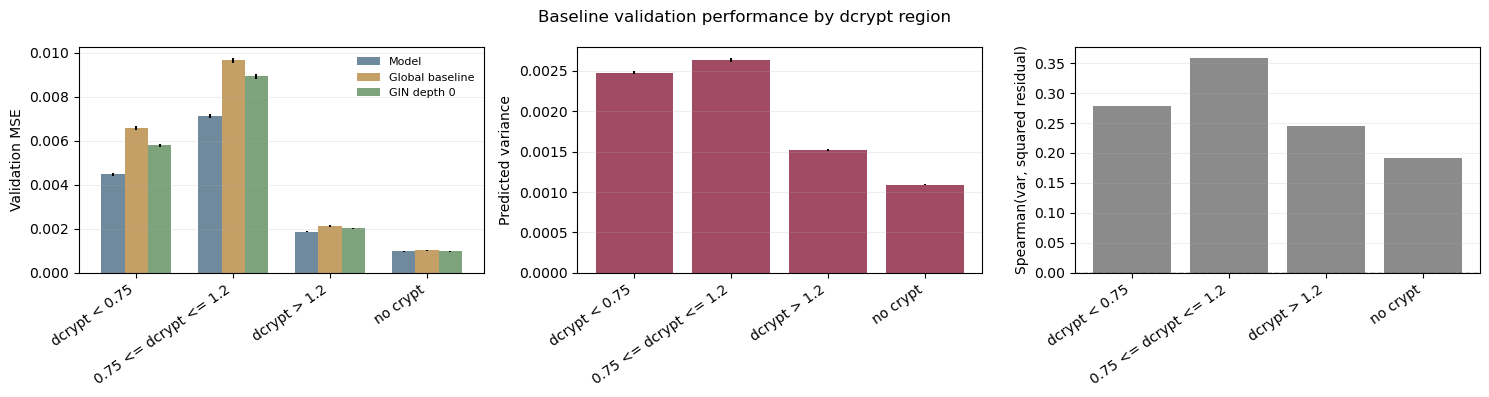

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/baseline_performance_by_crypt_lgr5_domain.pdf


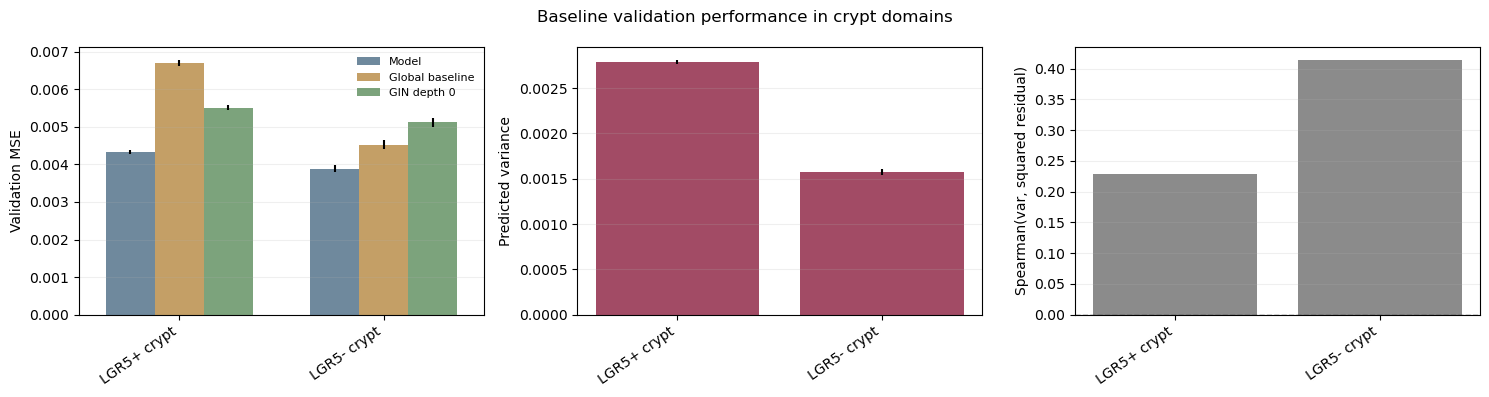

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/baseline_performance_by_crypt_marker_removal.pdf


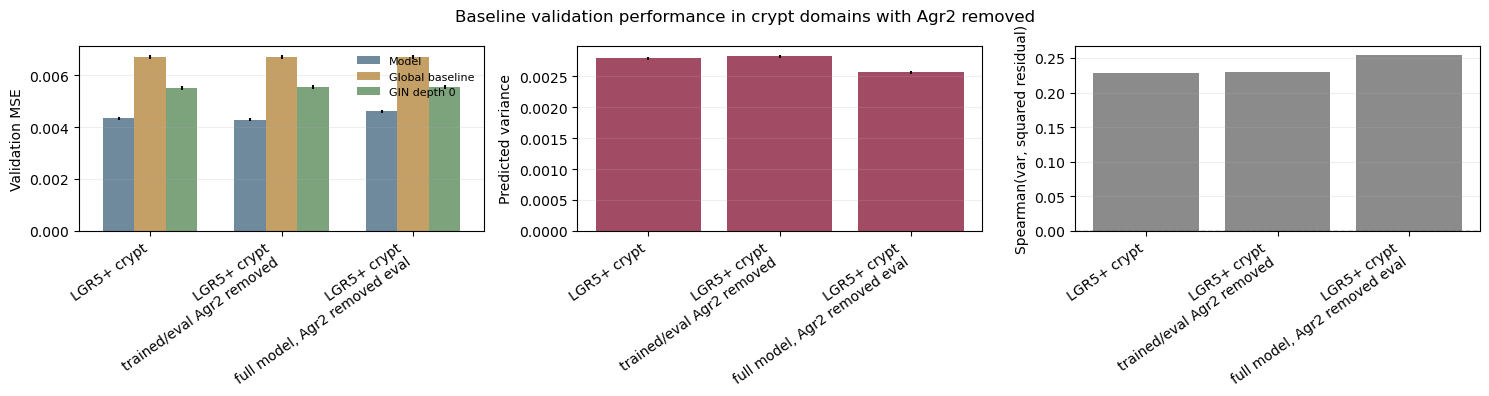

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: ylabel='Validation MSE'>,
        <Axes: ylabel='Predicted variance'>,
        <Axes: ylabel='Spearman(var, squared residual)'>], dtype=object))

In [38]:
def plot_baseline_performance(plot_df, title, filename, *, metric_specs=None, metric_ylabel="Validation MSE"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    x = np.arange(len(plot_df))
    labels = plot_df["label"].tolist()

    if metric_specs is None:
        metric_specs = [
            ("Model", "mse", "sem_mse", "#4f6f88"),
            ("Global baseline", "mse_global_baseline", "sem_mse_global_baseline", "#b88a44"),
            ("GIN depth 0", "mse_gin_depth0", "sem_mse_gin_depth0", "#5f8f5f"),
        ]
    width = 0.24
    offsets = (np.arange(len(metric_specs)) - (len(metric_specs) - 1) / 2) * width
    for offset, (label, value_col, sem_col, color) in zip(offsets, metric_specs):
        axes[0].bar(
            x + offset,
            plot_df[value_col],
            yerr=plot_df[sem_col],
            width=width,
            label=label,
            color=color,
            alpha=0.82,
            capsize=2,
        )
    axes[0].set_ylabel(metric_ylabel)
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].bar(x, plot_df["pred_var_mean"], yerr=plot_df["sem_pred_var"], color="#8b1e3f", alpha=0.8, capsize=2)
    axes[1].set_ylabel("Predicted variance")

    axes[2].bar(x, plot_df["spearman_pred_var_sqerr"], color="#6e6e6e", alpha=0.8)
    axes[2].axhline(0, color="0.25", linestyle="--", linewidth=1)
    axes[2].set_ylabel("Spearman(var, squared residual)")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.grid(True, axis="y", alpha=0.2)

    fig.suptitle(title)
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


ERROR_METRIC_FIGURE_SPECS = [
    {
        "suffix": "mse",
        "ylabel": "Validation MSE",
        "title_metric": "MSE",
        "metric_specs": [
            ("Model", "mse", "sem_mse", "#4f6f88"),
            ("Global baseline", "mse_global_baseline", "sem_mse_global_baseline", "#b88a44"),
            ("GIN depth 0", "mse_gin_depth0", "sem_mse_gin_depth0", "#5f8f5f"),
        ],
    },
    {
        "suffix": "mae",
        "ylabel": "Validation MAE",
        "title_metric": "MAE",
        "metric_specs": [
            ("Model", "mae", "sem_mae", "#4f6f88"),
            ("Global baseline", "mae_global_baseline", "sem_mae_global_baseline", "#b88a44"),
            ("GIN depth 0", "mae_gin_depth0", "sem_mae_gin_depth0", "#5f8f5f"),
        ],
    },
    {
        "suffix": "relative_error_vs_global_baseline",
        "ylabel": "Mean absolute error / |global baseline prediction|",
        "title_metric": "relative error to global baseline prediction",
        "metric_specs": [
            ("Model", "mean_relative_error", "sem_mean_relative_error", "#4f6f88"),
            ("Global baseline", "mean_relative_error_global_baseline", "sem_mean_relative_error_global_baseline", "#b88a44"),
            ("GIN depth 0", "mean_relative_error_gin_depth0", "sem_mean_relative_error_gin_depth0", "#5f8f5f"),
        ],
    },
]

BASELINE_PERFORMANCE_GROUPS = [
    (DCRYPT_REGION_ORDER, "dcrypt_region", "by dcrypt region"),
    (CRYPT_COMPARISON_ORDER, "crypt_lgr5_domain", "in crypt domains"),
    (CRYPT_MARKER_REMOVAL_COMPARISON_ORDER, "crypt_marker_removal", "in crypt marker-removal contexts"),
]

for metric_spec in ERROR_METRIC_FIGURE_SPECS:
    for group_order, suffix, title_suffix in BASELINE_PERFORMANCE_GROUPS:
        plot_baseline_performance(
            baseline_region_df[baseline_region_df["group"].isin(group_order)],
            f"Baseline validation {metric_spec['title_metric']} {title_suffix}",
            f"baseline_performance_{metric_spec['suffix']}_by_{suffix}",
            metric_specs=metric_spec["metric_specs"],
            metric_ylabel=metric_spec["ylabel"],
        )


**Local Marker Counts**

For every validation node, count how many positive cells of each marker lie inside the model receptive field. These counts summarize the marker context available to the trained GIN.

In [39]:
from src.graph.neighborhood import compute_hop_rings


def count_markers_in_receptive_field_for_graph(graph, marker_names_in, num_hops):
    n_nodes = int(graph.x.shape[0])
    n_markers = len(marker_names_in)
    x = graph.x.detach().cpu().numpy() if hasattr(graph.x, "detach") else np.asarray(graph.x)
    xb = x[:, :n_markers] > 0.5
    counts = np.zeros((n_nodes, n_markers), dtype=np.int32)
    for center in range(n_nodes):
        rings = compute_hop_rings(graph.edge_index, center, int(num_hops))
        nodes = np.asarray([node for ring in rings for node in ring], dtype=int)
        if len(nodes):
            counts[center] = xb[nodes].sum(axis=0)
    return counts


def receptive_field_counts_for_graphs(graphs_in):
    counts_by_graph = []
    for gi, g in enumerate(graphs_in):
        counts_by_graph.append(count_markers_in_receptive_field_for_graph(g, marker_names, LOCAL_COUNT_HOPS))
        if (gi + 1) % 25 == 0:
            print(f"Computed RF marker counts for {gi + 1}/{len(graphs_in)} graphs")
    return np.concatenate(counts_by_graph, axis=0)


def center_marker_positive_matrix(graphs_in, marker_names_in):
    n_markers = len(marker_names_in)
    parts = []
    for g in graphs_in:
        x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
        parts.append(x[:, :n_markers] > 0.5)
    return np.concatenate(parts, axis=0)


rf_marker_counts = receptive_field_counts_for_graphs(g_val)
center_marker_positive = center_marker_positive_matrix(g_val, marker_names)
rf_count_contexts = {
    "full": rf_marker_counts,
}
center_marker_positive_contexts = {
    "full": center_marker_positive,
}

for spec in REMOVAL_SETS:
    key = spec["key"]
    graphs_removed = removal_variant_graphs[key]["val"]
    rf_counts_removed = receptive_field_counts_for_graphs(graphs_removed)
    center_positive_removed = center_marker_positive_matrix(graphs_removed, marker_names)
    rf_count_contexts[f"{key}_train_eval"] = rf_counts_removed
    rf_count_contexts[f"{key}_eval_only"] = rf_counts_removed
    center_marker_positive_contexts[f"{key}_train_eval"] = center_positive_removed
    center_marker_positive_contexts[f"{key}_eval_only"] = center_positive_removed

print("rf_marker_counts shape:", rf_marker_counts.shape)


Computed RF marker counts for 25/240 graphs
Computed RF marker counts for 50/240 graphs
Computed RF marker counts for 75/240 graphs
Computed RF marker counts for 100/240 graphs
Computed RF marker counts for 125/240 graphs
Computed RF marker counts for 150/240 graphs
Computed RF marker counts for 175/240 graphs
Computed RF marker counts for 200/240 graphs
Computed RF marker counts for 225/240 graphs
rf_marker_counts shape: (110922, 7)


**Marker Count Summary Table**

This table shows, for each region and marker, the average receptive-field count, how often the marker is visible, and Spearman correlations with true curvature, predicted curvature, squared residuals, and predicted variance.

In [40]:
def summarize_marker_counts_by_group(group_masks):
    rows = []
    for group in ANALYSIS_GROUP_ORDER:
        mask = np.asarray(group_masks[group], dtype=bool)
        pred_ctx = arrays_for_group(group)
        context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
        rf_counts = rf_count_contexts[context_name]
        center_marker_positive = center_marker_positive_contexts[context_name]
        n = int(mask.sum())
        for mi, marker in enumerate(marker_names):
            counts = rf_counts[:, mi]
            if n == 0:
                n_marker_positive = 0
                mean_count = frac_visible = rho_true = rho_pred = rho_sqerr = rho_var = np.nan
            else:
                c = counts[mask]
                n_marker_positive = int(center_marker_positive[mask, mi].sum())
                mean_count = float(np.mean(c))
                frac_visible = float(np.mean(c > 0))
                rho_true = spearman_corr(c, pred_ctx["y_true"][mask])
                rho_pred = spearman_corr(c, pred_ctx["y_pred"][mask])
                rho_sqerr = spearman_corr(c, pred_ctx["sqerr"][mask])
                rho_var = spearman_corr(c, pred_ctx["pred_var"][mask])
            rows.append({
                "group": group,
                "label": DCRYPT_REGION_LABELS[group],
                "model_context": MODEL_CONTEXT_BY_GROUP.get(group, "full"),
                "marker": marker,
                "marker_index": mi,
                "n_nodes": n,
                "n_marker_positive": n_marker_positive,
                "mean_count_within_rf": mean_count,
                "fraction_with_marker_visible": frac_visible,
                "spearman_count_true": rho_true,
                "spearman_count_pred": rho_pred,
                "spearman_count_sqerr": rho_sqerr,
                "spearman_count_pred_var": rho_var,
            })
    return pd.DataFrame(rows)


marker_count_region_df = summarize_marker_counts_by_group(analysis_masks)
display_table(marker_count_region_df, head=12)

,label,model_context,marker,marker_index,n_nodes,n_marker_positive,mean_count_within_rf,fraction_with_marker_visible,spearman_count_true,spearman_count_pred,spearman_count_sqerr,spearman_count_pred_var
0,dcrypt < 0.75,full,Agr2,0,20385,1664,1.489625,0.586019,0.210317,0.403575,0.059243,0.309465
1,dcrypt < 0.75,full,AldoB,1,20385,4674,4.726662,0.377140,-0.159053,-0.257117,-0.107475,-0.490505
2,dcrypt < 0.75,full,Chroma,2,20385,256,0.221486,0.120285,0.125691,0.235684,0.051305,0.175416
3,dcrypt < 0.75,full,KI67,3,20385,9026,8.565710,0.795732,0.016114,0.136925,-0.001857,0.277296
4,dcrypt < 0.75,full,LGR5,4,20385,6975,6.321903,0.585038,0.193135,0.447295,0.045254,0.325281
5,dcrypt < 0.75,full,Lysozyme,5,20385,1497,1.261516,0.396125,0.269070,0.570577,0.054232,0.397989
6,dcrypt < 0.75,full,Serotonin,6,20385,210,0.176993,0.119107,0.178905,0.308928,0.085526,0.229144
7,0.75 <= dcrypt <= 1.2,full,Agr2,0,25951,1215,0.969866,0.423837,0.125771,0.240934,-0.027975,0.110870
8,0.75 <= dcrypt <= 1.2,full,AldoB,1,25951,9826,7.621440,0.661709,-0.058041,-0.143196,-0.028618,-0.241454
9,0.75 <= dcrypt <= 1.2,full,Chroma,2,25951,77,0.069246,0.045278,0.060598,0.124454,0.004843,0.103780


**Marker Count Heatmaps**

Heatmaps summarize local marker composition and marker-count correlations. The four dcrypt regions are plotted separately from the LGR5 crypt-domain comparison and from the whole-organoid crypt-marker removal comparison.


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/mean_rf_marker_count_by_dcrypt_regions.pdf


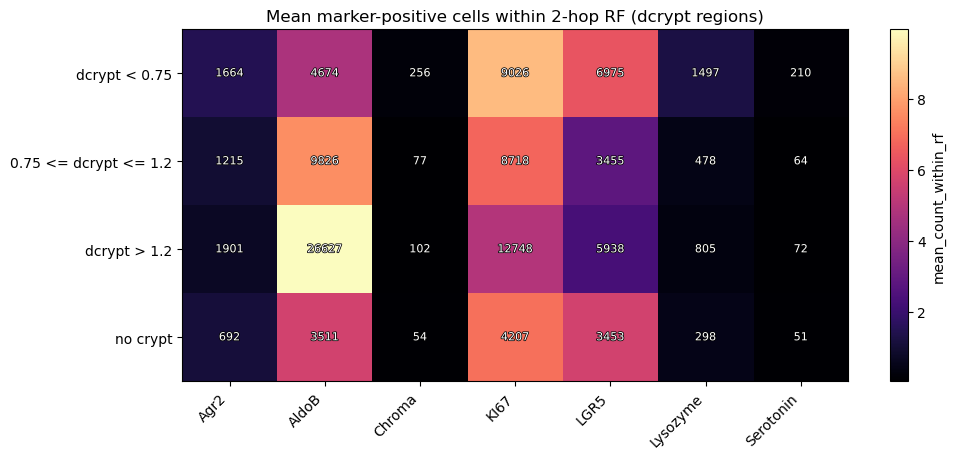

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_sqerr_by_dcrypt_regions.pdf


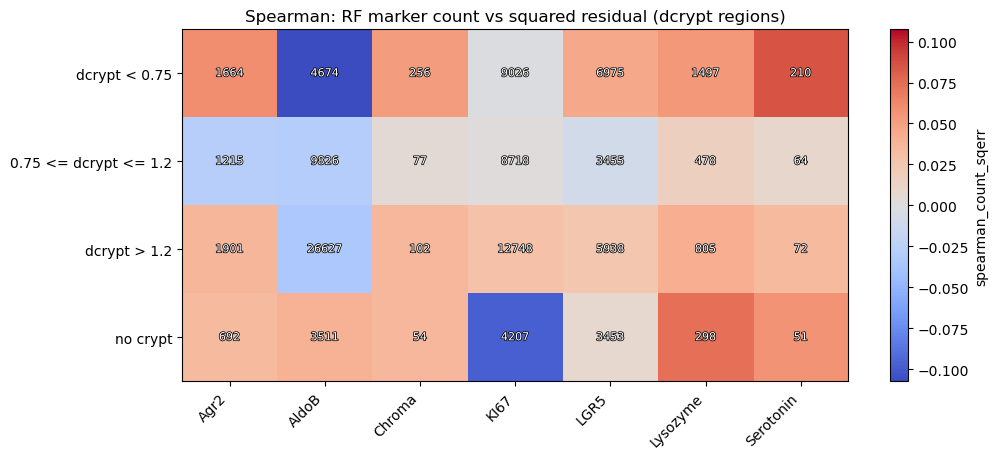

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_prediction_by_dcrypt_regions.pdf


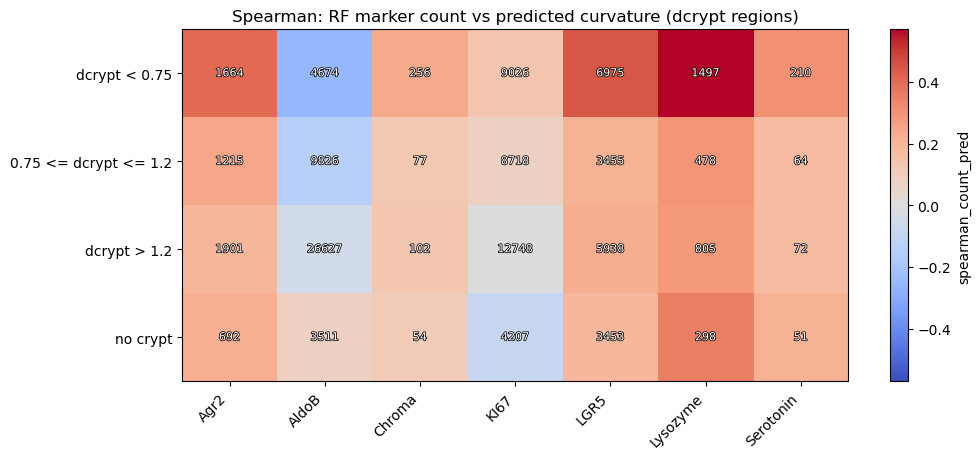

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_predicted_variance_by_dcrypt_regions.pdf


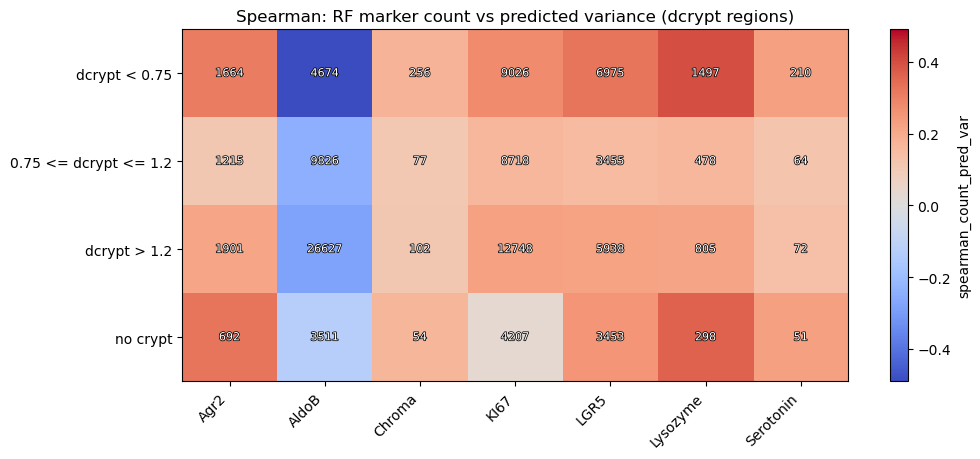

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_true_curvature_by_dcrypt_regions.pdf


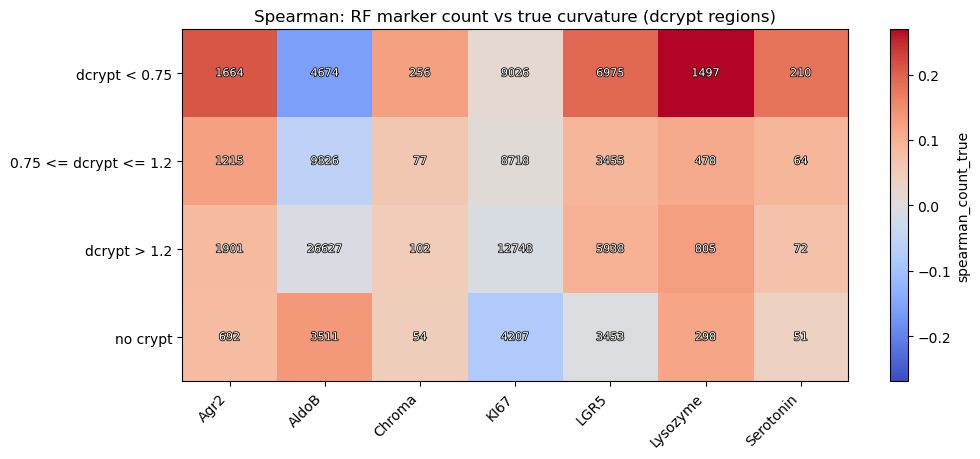

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/mean_rf_marker_count_by_crypt_lgr5_domains.pdf


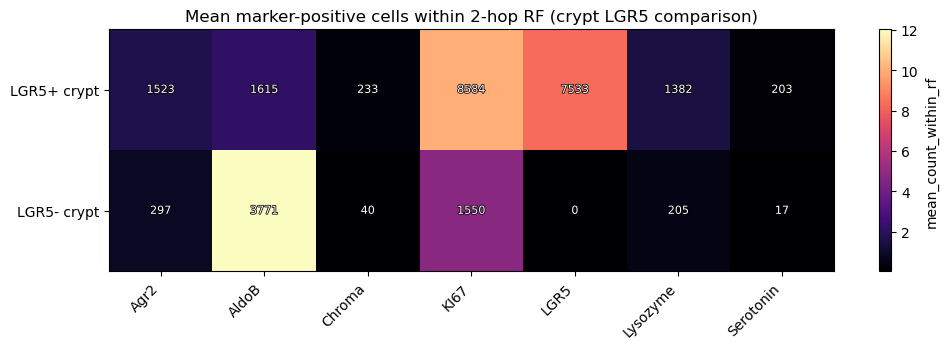

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_sqerr_by_crypt_lgr5_domains.pdf


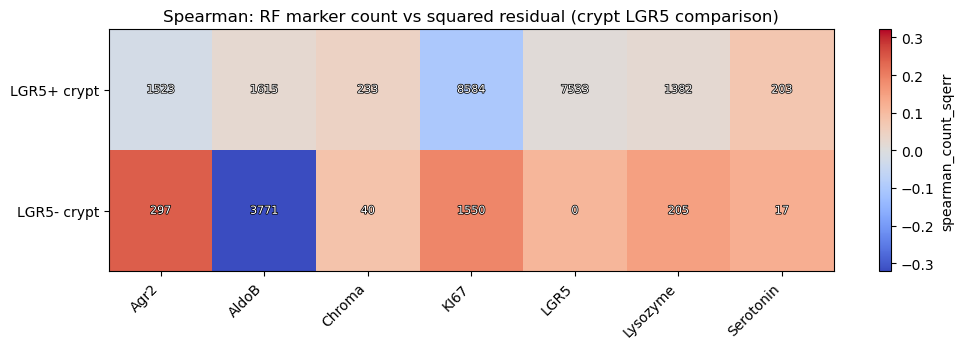

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_prediction_by_crypt_lgr5_domains.pdf


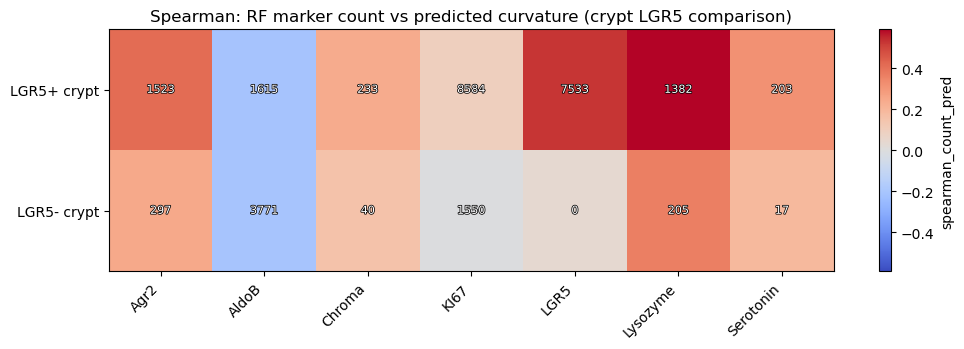

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_predicted_variance_by_crypt_lgr5_domains.pdf


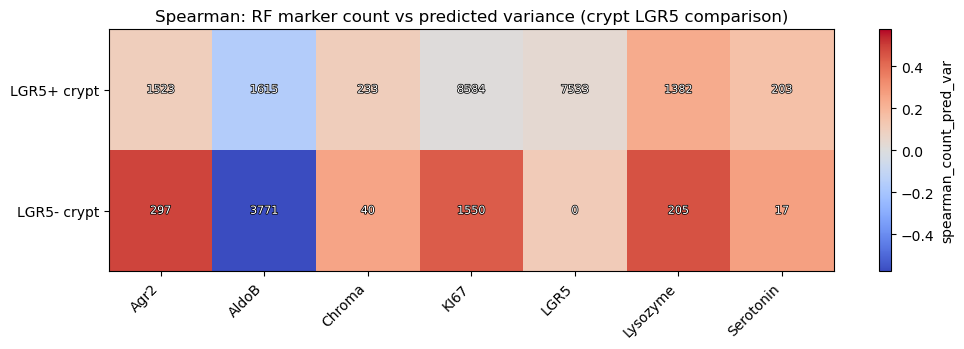

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_true_curvature_by_crypt_lgr5_domains.pdf


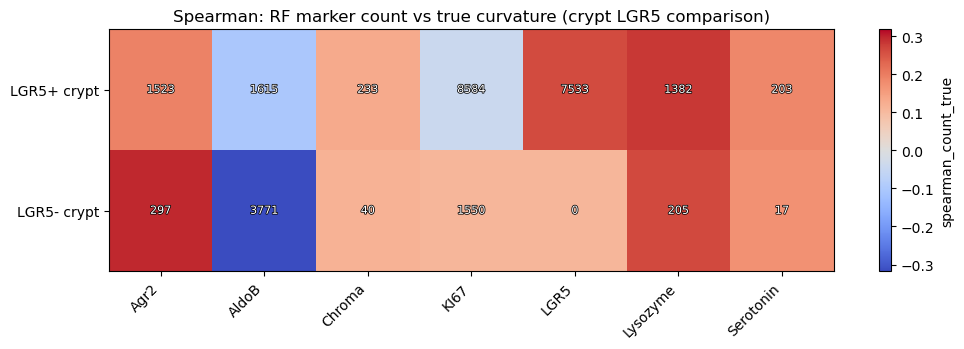

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/mean_rf_marker_count_by_crypt_marker_removal.pdf


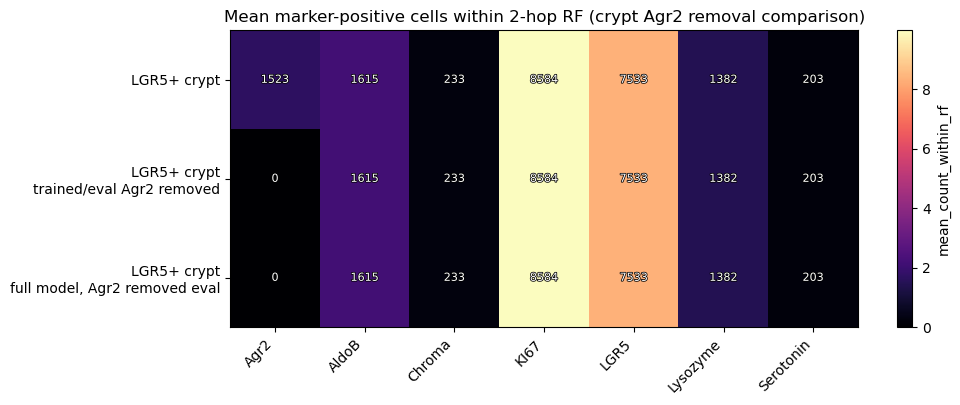

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_sqerr_by_crypt_marker_removal.pdf


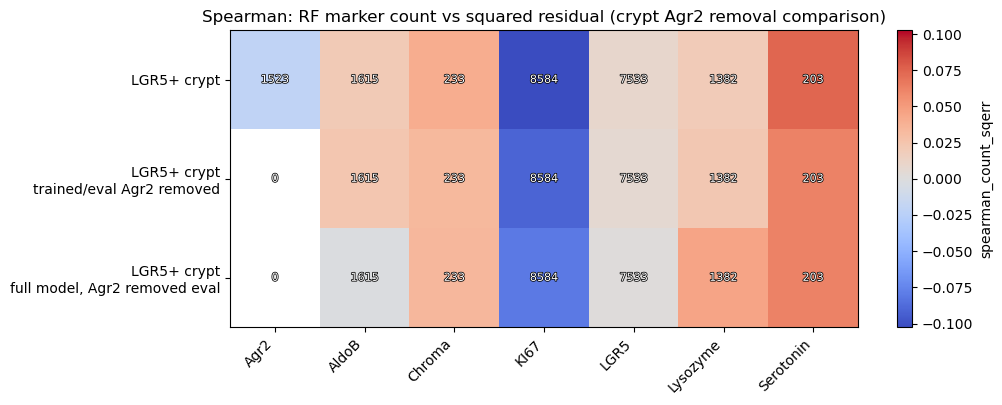

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_prediction_by_crypt_marker_removal.pdf


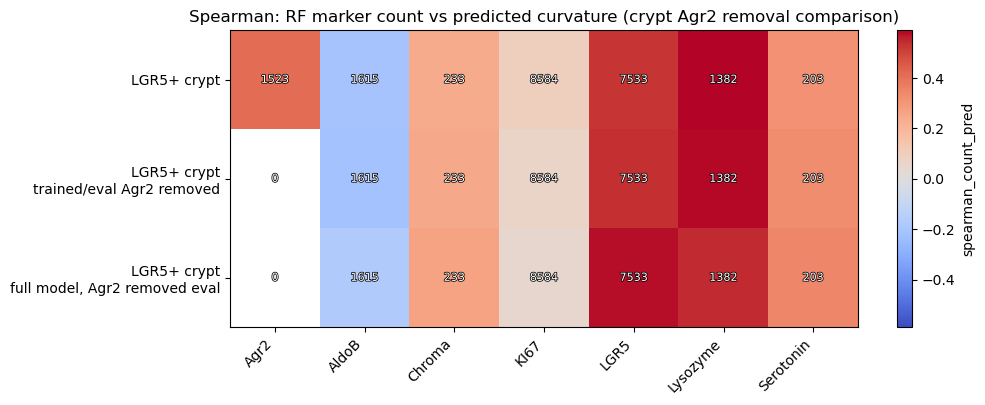

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_predicted_variance_by_crypt_marker_removal.pdf


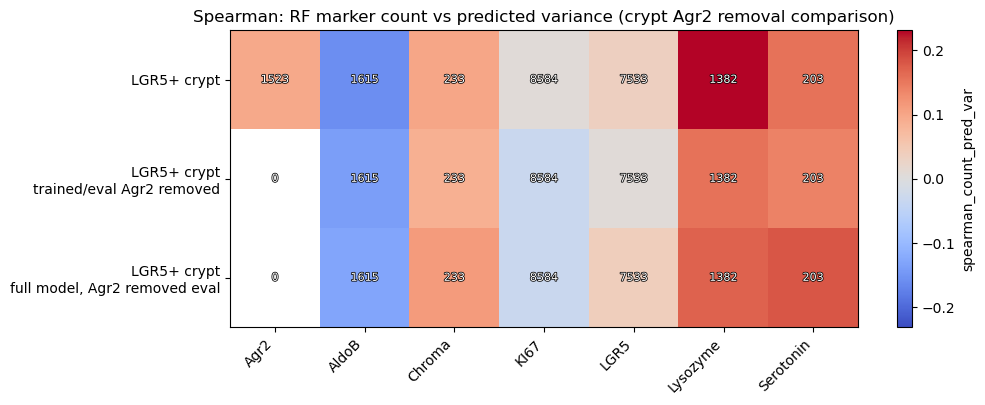

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/spearman_rf_marker_count_vs_true_curvature_by_crypt_marker_removal.pdf


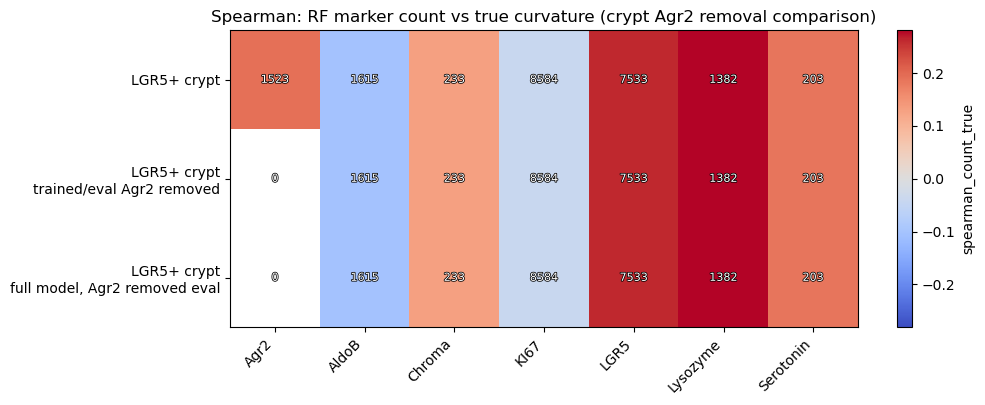

In [41]:
def annotate_heatmap_cells(ax, annotation_table, *, fontsize=8):
    values = annotation_table.to_numpy()
    for yi in range(values.shape[0]):
        for xi in range(values.shape[1]):
            value = values[yi, xi]
            if pd.isna(value):
                continue
            text = ax.text(
                xi,
                yi,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=fontsize,
                color="white",
            )
            text.set_path_effects([path_effects.withStroke(linewidth=1.1, foreground="black")])


def plot_group_marker_heatmap(
    df,
    value_col,
    title,
    filename,
    *,
    group_order,
    cmap="viridis",
    center_zero=False,
    annotation_col="n_marker_positive",
):
    sub = df[df["group"].isin(group_order)].copy()
    table = sub.pivot(index="label", columns="marker", values=value_col)
    row_labels = [DCRYPT_REGION_LABELS[g] for g in group_order if g in set(sub["group"])]
    table = table.reindex(row_labels)
    table = table[[m for m in marker_names if m in table.columns]]

    annotation_table = None
    if annotation_col is not None and annotation_col in sub.columns:
        annotation_table = sub.pivot(index="label", columns="marker", values=annotation_col)
        annotation_table = annotation_table.reindex(row_labels)
        annotation_table = annotation_table.reindex(columns=table.columns)

    fig, ax = plt.subplots(figsize=(1.05 * len(table.columns) + 3, 0.55 * len(table.index) + 2.5))
    values = table.to_numpy(dtype=float)
    if center_zero:
        vmax = np.nanmax(np.abs(values)) if np.any(np.isfinite(values)) else 1.0
        vmin = -vmax
    else:
        vmin = None
        vmax = None
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_title(title)
    if annotation_table is not None:
        annotate_heatmap_cells(ax, annotation_table)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_col)
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


for group_order, suffix, title_prefix in [
    (DCRYPT_REGION_ORDER, "dcrypt_regions", "dcrypt regions"),
    (CRYPT_COMPARISON_ORDER, "crypt_lgr5_domains", "crypt LGR5 comparison"),
    (CRYPT_MARKER_REMOVAL_COMPARISON_ORDER, "crypt_marker_removal", "crypt marker-removal comparison"),
]:
    plot_group_marker_heatmap(
        marker_count_region_df,
        "mean_count_within_rf",
        f"Mean marker-positive cells within {LOCAL_COUNT_HOPS}-hop RF ({title_prefix})",
        f"mean_rf_marker_count_by_{suffix}",
        group_order=group_order,
        cmap="magma",
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_sqerr",
        f"Spearman: RF marker count vs squared residual ({title_prefix})",
        f"spearman_rf_marker_count_vs_sqerr_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_pred",
        f"Spearman: RF marker count vs predicted curvature ({title_prefix})",
        f"spearman_rf_marker_count_vs_prediction_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_pred_var",
        f"Spearman: RF marker count vs predicted variance ({title_prefix})",
        f"spearman_rf_marker_count_vs_predicted_variance_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )
    plot_group_marker_heatmap(
        marker_count_region_df,
        "spearman_count_true",
        f"Spearman: RF marker count vs true curvature ({title_prefix})",
        f"spearman_rf_marker_count_vs_true_curvature_by_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
    )


**True Curvature By Region And Marker**

For each region, summarize the true curvature of nodes that are positive for each fate marker. The heatmaps show the mean and standard deviation; cell annotations show the number of marker-positive nodes contributing to each estimate.


,label,marker,marker_index,n_region_nodes,region_true_curvature_mean,region_true_curvature_std,n_marker_positive,true_curvature_mean,true_curvature_mean_minus_region_mean,true_curvature_std,true_curvature_sem
0,dcrypt < 0.75,Agr2,0,20385,0.089179,0.062384,1664,0.105111,0.015932,0.065612,0.001608
1,dcrypt < 0.75,AldoB,1,20385,0.089179,0.062384,4674,0.066059,-0.023120,0.040821,0.000597
2,dcrypt < 0.75,Chroma,2,20385,0.089179,0.062384,256,0.122000,0.032821,0.064042,0.004003
3,dcrypt < 0.75,KI67,3,20385,0.089179,0.062384,9026,0.089865,0.000686,0.064040,0.000674
4,dcrypt < 0.75,LGR5,4,20385,0.089179,0.062384,6975,0.103922,0.014743,0.063017,0.000755
5,dcrypt < 0.75,Lysozyme,5,20385,0.089179,0.062384,1497,0.118665,0.029487,0.064525,0.001668
6,dcrypt < 0.75,Serotonin,6,20385,0.089179,0.062384,210,0.144922,0.055743,0.076405,0.005272
7,0.75 <= dcrypt <= 1.2,Agr2,0,25951,-0.013229,0.087774,1215,0.012023,0.025252,0.077138,0.002213
8,0.75 <= dcrypt <= 1.2,AldoB,1,25951,-0.013229,0.087774,9826,-0.018127,-0.004898,0.089353,0.000901
9,0.75 <= dcrypt <= 1.2,Chroma,2,25951,-0.013229,0.087774,77,0.033320,0.046549,0.075482,0.008602


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_mean_by_marker_dcrypt_regions.pdf


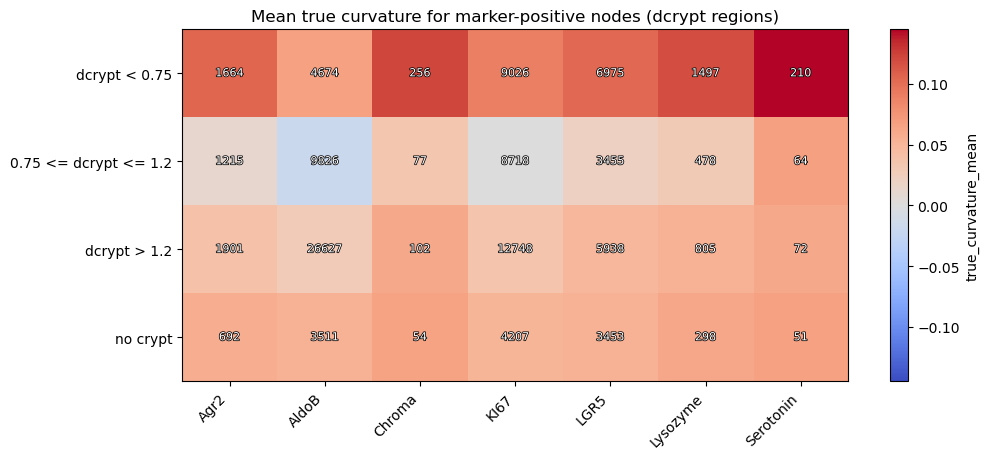

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_mean_minus_region_mean_by_marker_dcrypt_regions.pdf


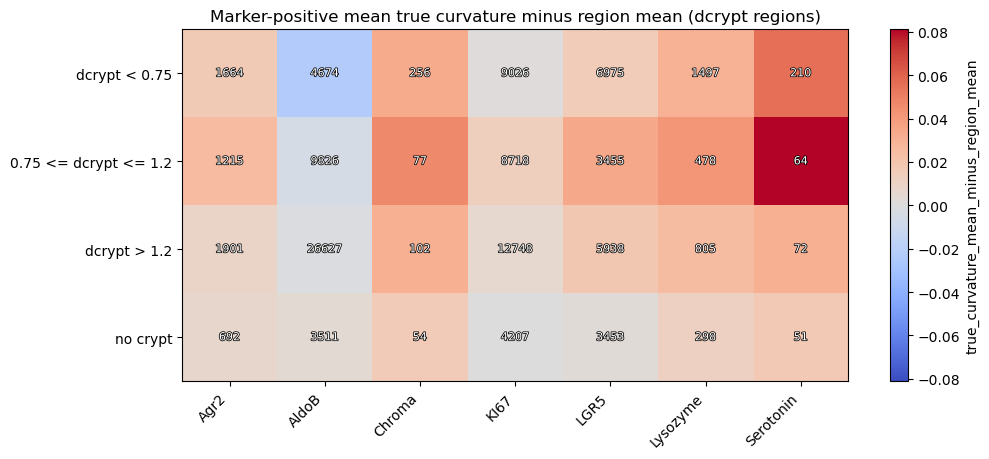

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_std_by_marker_dcrypt_regions.pdf


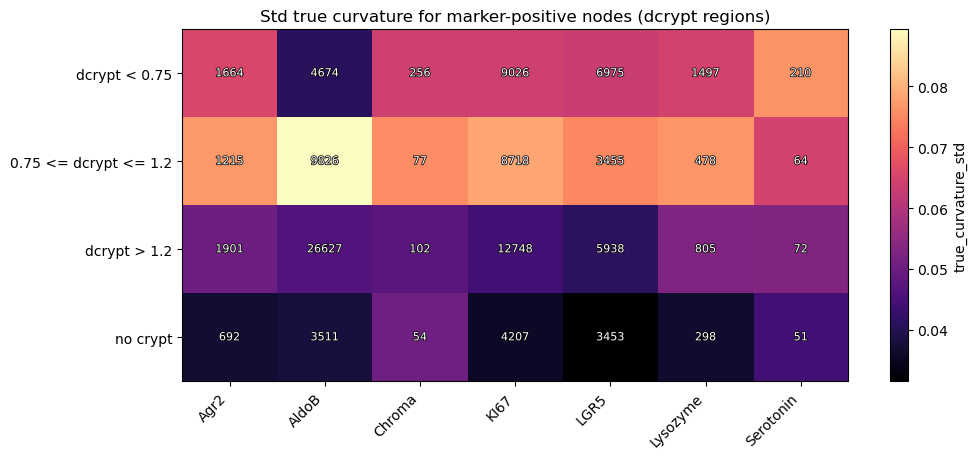

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_mean_by_marker_crypt_lgr5_domains.pdf


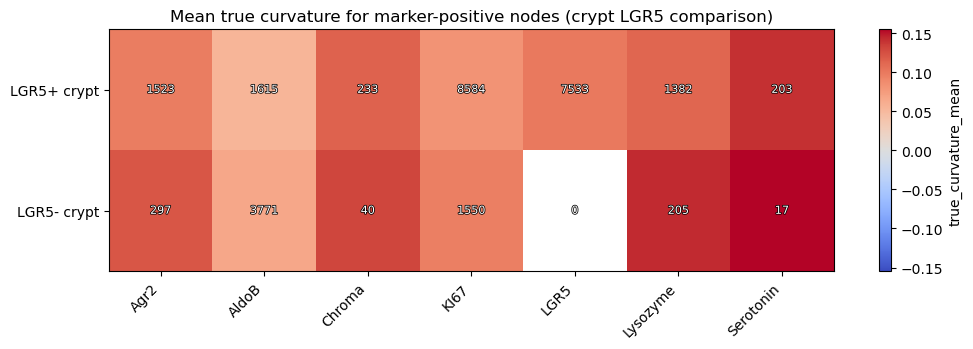

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_mean_minus_region_mean_by_marker_crypt_lgr5_domains.pdf


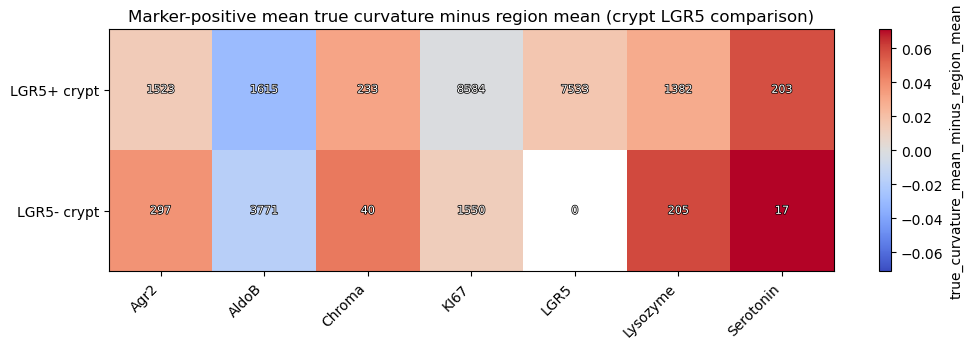

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_std_by_marker_crypt_lgr5_domains.pdf


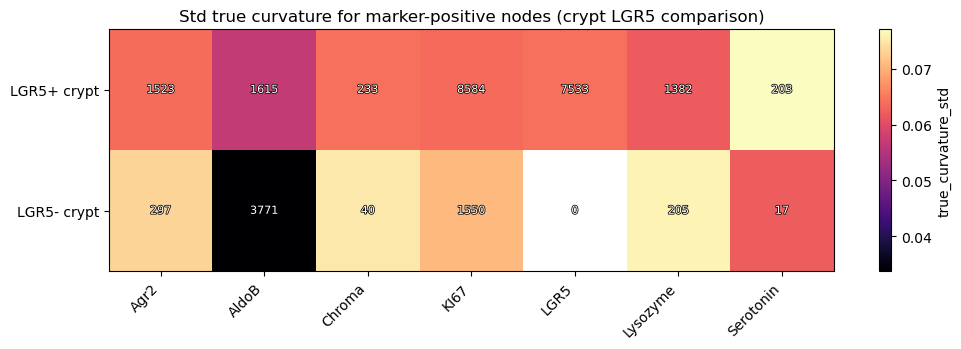

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_mean_by_marker_crypt_marker_removal.pdf


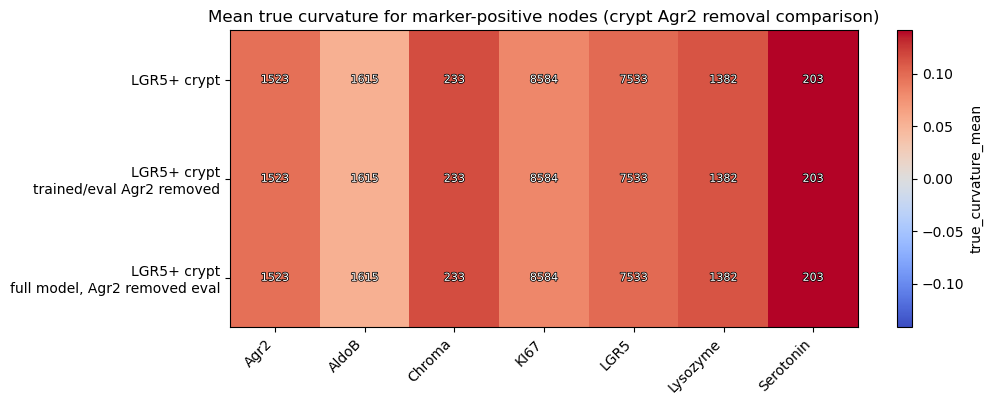

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_mean_minus_region_mean_by_marker_crypt_marker_removal.pdf


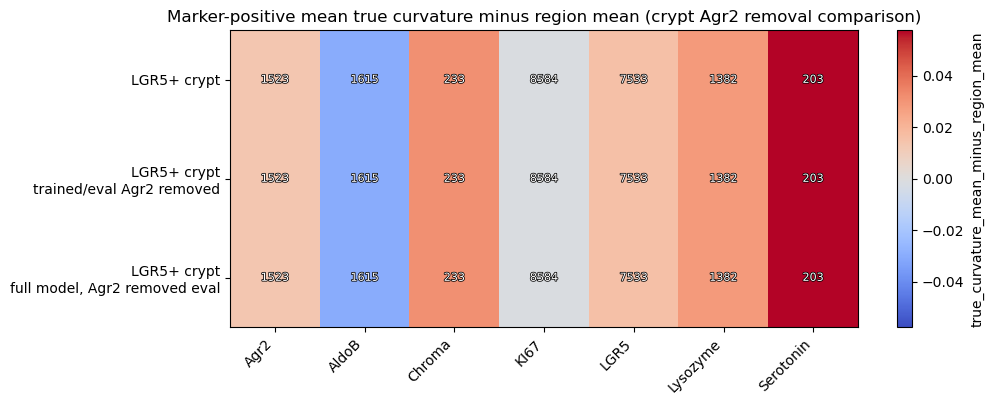

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/true_curvature_std_by_marker_crypt_marker_removal.pdf


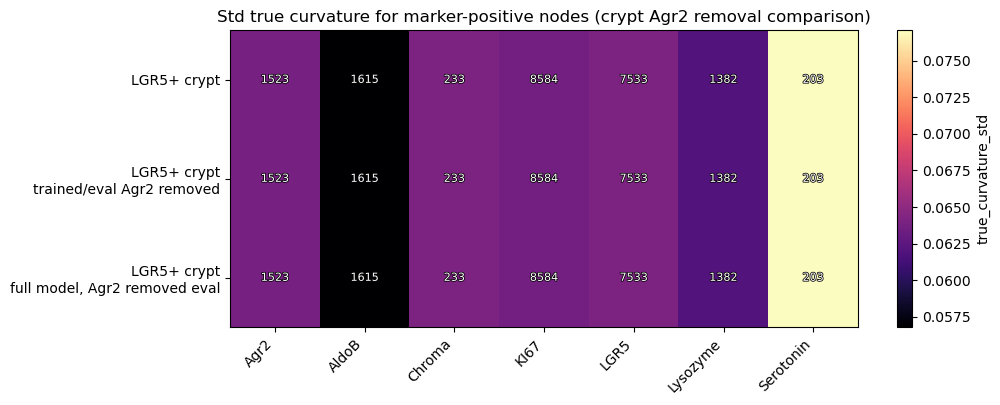

In [42]:
def summarize_true_curvature_by_region_marker(group_masks):
    rows = []
    y_true_values = np.asarray(y_true, dtype=float).reshape(-1)
    marker_positive = center_marker_positive_contexts["full"]
    for group in ANALYSIS_GROUP_ORDER:
        group_mask = np.asarray(group_masks[group], dtype=bool)
        region_values = y_true_values[group_mask]
        region_n = int(region_values.size)
        region_mean = float(np.mean(region_values)) if region_n else np.nan
        region_std = float(np.std(region_values, ddof=1)) if region_n > 1 else (0.0 if region_n == 1 else np.nan)
        for mi, marker in enumerate(marker_names):
            mask = group_mask & marker_positive[:, mi]
            values = y_true_values[mask]
            n = int(values.size)
            if n == 0:
                mean_true = std_true = sem_true = np.nan
            else:
                mean_true = float(np.mean(values))
                std_true = float(np.std(values, ddof=1)) if n > 1 else 0.0
                sem_true = float(std_true / np.sqrt(n)) if n > 1 else 0.0
            rows.append({
                "group": group,
                "label": DCRYPT_REGION_LABELS[group],
                "marker": marker,
                "marker_index": mi,
                "n_region_nodes": region_n,
                "region_true_curvature_mean": region_mean,
                "region_true_curvature_std": region_std,
                "n_marker_positive": n,
                "true_curvature_mean": mean_true,
                "true_curvature_mean_minus_region_mean": (mean_true - region_mean) if np.isfinite(mean_true) and np.isfinite(region_mean) else np.nan,
                "true_curvature_std": std_true,
                "true_curvature_sem": sem_true,
            })
    return pd.DataFrame(rows)


true_curvature_marker_region_df = summarize_true_curvature_by_region_marker(analysis_masks)
display_table(true_curvature_marker_region_df, head=12)


for group_order, suffix, title_prefix in [
    (DCRYPT_REGION_ORDER, "dcrypt_regions", "dcrypt regions"),
    (CRYPT_COMPARISON_ORDER, "crypt_lgr5_domains", "crypt LGR5 comparison"),
    (CRYPT_MARKER_REMOVAL_COMPARISON_ORDER, "crypt_marker_removal", "crypt marker-removal comparison"),
]:
    plot_group_marker_heatmap(
        true_curvature_marker_region_df,
        "true_curvature_mean",
        f"Mean true curvature for marker-positive nodes ({title_prefix})",
        f"true_curvature_mean_by_marker_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
        annotation_col="n_marker_positive",
    )
    plot_group_marker_heatmap(
        true_curvature_marker_region_df,
        "true_curvature_mean_minus_region_mean",
        f"Marker-positive mean true curvature minus region mean ({title_prefix})",
        f"true_curvature_mean_minus_region_mean_by_marker_{suffix}",
        group_order=group_order,
        cmap="coolwarm",
        center_zero=True,
        annotation_col="n_marker_positive",
    )
    plot_group_marker_heatmap(
        true_curvature_marker_region_df,
        "true_curvature_std",
        f"Std true curvature for marker-positive nodes ({title_prefix})",
        f"true_curvature_std_by_marker_{suffix}",
        group_order=group_order,
        cmap="magma",
        center_zero=False,
        annotation_col="n_marker_positive",
    )


**Ablation Subgraphs**

Build sampled ego-subgraphs centered on nodes from each analysis group. These subgraphs are used for marker-removal perturbations.

In [43]:
from src.analysis.perturbation import (
    _accumulate_scalar_effects,
    _prepare_perturbation_run,
    _subgraph_center_targets,
    compute_perturbation_influence_maps,
    compute_perturbation_mse_influence_maps,
    predict_subgraph_center_distribution,
)
from src.data.subgraphs import build_ego_subgraphs_for_center_specs


def center_specs_from_flat_mask(graphs_in, flat_mask, *, max_centers=None, seed=0):
    flat_mask = np.asarray(flat_mask, dtype=bool).reshape(-1)
    specs = []
    offset = 0
    for gi, g in enumerate(graphs_in):
        n = int(g.x.shape[0])
        local = np.where(flat_mask[offset:offset + n])[0]
        specs.extend((gi, int(c)) for c in local)
        offset += n
    if max_centers is not None and len(specs) > int(max_centers):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(specs), size=int(max_centers), replace=False)
        specs = [specs[int(i)] for i in idx]
    return specs


def build_group_subgraphs(group_masks):
    out = {}
    info = []
    for group in ANALYSIS_GROUP_ORDER:
        context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
        graphs_for_group = model_contexts[context_name]["graphs"]
        specs = center_specs_from_flat_mask(
            graphs_for_group,
            group_masks[group],
            max_centers=MAX_SUBGRAPHS_PER_GROUP,
            seed=RANDOM_SEED,
        )
        if len(specs) == 0:
            out[group] = []
        else:
            out[group] = build_ego_subgraphs_for_center_specs(
                graphs_for_group,
                specs,
                num_hops=NUM_LAYERS,
                copy_graph_level_attrs=True,
            )
        info.append({
            "group": group,
            "label": DCRYPT_REGION_LABELS[group],
            "model_context": context_name,
            "n_nodes": int(np.asarray(group_masks[group], dtype=bool).sum()),
            "n_subgraphs": len(out[group]),
        })
    return out, pd.DataFrame(info)


group_subgraphs, group_subgraph_info = build_group_subgraphs(analysis_masks)
display_table(group_subgraph_info)

,label,model_context,n_nodes,n_subgraphs
0,dcrypt < 0.75,full,20385,2000
1,0.75 <= dcrypt <= 1.2,full,25951,2000
2,dcrypt > 1.2,full,52487,2000
3,no crypt,full,12099,2000
4,LGR5+ crypt,full,16685,2000
5,LGR5- crypt,full,6253,2000
6,LGR5+ crypt\ntrained/eval Agr2 removed,crypt_markers_removed,16685,2000
7,"LGR5+ crypt\nfull model, Agr2 removed eval",full_eval_crypt_markers_removed,16685,2000


**Marker Ablation**

For each sampled center cell, marker-positive neighbors are removed either one at a time (`single` mode) or all together (`all` mode). The table records how removal changes predicted curvature and squared error by hop distance and marker.


In [44]:
def _inverse_center_distribution_for_subgraphs(y, mu, log_var, graphs):
    if target_transform is None:
        return y, mu, log_var
    y_out, mu_out, log_var_out = target_transform.inverse_distribution(
        y,
        mu,
        log_var=log_var,
        graphs=graphs,
        center_only=True,
        target_index=TARGET_INDEX_FOR_PLOTS,
    )
    y_out = None if y_out is None else np.asarray(y_out, dtype=np.float64)
    mu_out = None if mu_out is None else np.asarray(mu_out, dtype=np.float64)
    log_var_out = None if log_var_out is None else np.asarray(log_var_out, dtype=np.float64)
    return y_out, mu_out, log_var_out


def compute_perturbation_error_influence_maps(
    subgraphs,
    model,
    marker_names,
    *,
    k_hops,
    mode,
    normalize_by,
    metric,
    baseline_model=None,
):
    subs, n_markers, hops, center_x, perturbed, meta = _prepare_perturbation_run(
        subgraphs,
        marker_names,
        k_hops,
        mode,
        max_subgraphs=None,
    )
    y_center = _subgraph_center_targets(subs, target_index=TARGET_INDEX_FOR_PLOTS)
    base_mu, _ = predict_subgraph_center_distribution(
        subs,
        model,
        device=device,
        batch_size=PERTURBATION_BATCH_SIZE,
        target_index=TARGET_INDEX_FOR_PLOTS,
    )
    y_center, base_mu, _ = _inverse_center_distribution_for_subgraphs(
        y_center,
        base_mu,
        None,
        subs,
    )

    if len(perturbed):
        pert_mu, _ = predict_subgraph_center_distribution(
            perturbed,
            model,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
        )
        _, pert_mu, _ = _inverse_center_distribution_for_subgraphs(
            None,
            pert_mu,
            None,
            perturbed,
        )
    else:
        pert_mu = np.zeros((0,), dtype=np.float64)

    base_abs_err = np.abs(base_mu - y_center)
    if metric == "mae":
        base_metric = base_abs_err
        if len(meta):
            si_idx = np.asarray([si for si, _, _, _ in meta], dtype=int)
            pert_metric = np.abs(pert_mu - y_center[si_idx])
        else:
            pert_metric = np.zeros((0,), dtype=np.float64)
        key = "delta_mae"
    elif metric == "relative_error":
        if baseline_model is None:
            raise ValueError("baseline_model is required for relative_error.")
        baseline_mu, _ = predict_subgraph_center_distribution(
            subs,
            baseline_model,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
        )
        _, baseline_mu, _ = _inverse_center_distribution_for_subgraphs(
            None,
            baseline_mu,
            None,
            subs,
        )
        baseline_abs_pred = np.abs(baseline_mu)
        denom = np.where(baseline_abs_pred > RELATIVE_ERROR_EPS, baseline_abs_pred, np.nan)
        base_metric = base_abs_err / denom
        if len(meta):
            si_idx = np.asarray([si for si, _, _, _ in meta], dtype=int)
            pert_metric = np.abs(pert_mu - y_center[si_idx]) / denom[si_idx]
        else:
            pert_metric = np.zeros((0,), dtype=np.float64)
        key = "delta_relative_error"
    else:
        raise ValueError("metric must be 'mae' or 'relative_error'.")

    effects = []
    finite_meta = []
    for j, meta_row in enumerate(meta):
        si, _, _, _ = meta_row
        effect = float(pert_metric[j] - base_metric[si])
        if not np.isfinite(effect):
            continue
        effects.append(effect)
        finite_meta.append(meta_row)
    ag = _accumulate_scalar_effects(
        effects,
        finite_meta,
        center_x,
        len(hops),
        n_markers,
        normalize_total_by=normalize_by,
        normalize_center_by=normalize_by,
    )
    return {
        f"{key}_total": ag["total"],
        f"{key}_abs_total": ag["total_abs"],
        f"{key}_cmarker": ag["cmarker"],
        f"{key}_abs_cmarker": ag["cmarker_abs"],
        "counts_total": ag["counts_total"],
        "cases_total": ag["cases_total"],
        "counts_cmarker": ag["counts_cmarker"],
        "cases_cmarker": ag["cases_cmarker"],
        "hops": hops,
        "marker_names": marker_names,
        "target_index": TARGET_INDEX_FOR_PLOTS,
        "metric": metric,
        "normalize_total_by": normalize_by,
        "normalize_center_by": normalize_by,
    }


def perturbation_results_to_tables(result, mse_result, mae_result, rel_result, *, group, mode, normalize_by):
    rows = []
    hops = list(result["hops"])
    for hi, hop in enumerate(hops):
        for mi, marker in enumerate(marker_names):
            rows.append({
                "group": group,
                "label": DCRYPT_REGION_LABELS[group],
                "mode": mode,
                "normalize_by": normalize_by,
                "model_context": MODEL_CONTEXT_BY_GROUP.get(group, "full"),
                "hop": int(hop),
                "marker": marker,
                "marker_index": mi,
                "delta_mu": float(result["delta_mu_total"][hi, mi]),
                "abs_delta_mu": float(result["delta_mu_abs_total"][hi, mi]),
                "delta_mse": float(mse_result["delta_mse_total"][hi, mi]),
                "abs_delta_mse": float(mse_result["delta_mse_abs_total"][hi, mi]),
                "delta_mae": float(mae_result["delta_mae_total"][hi, mi]),
                "abs_delta_mae": float(mae_result["delta_mae_abs_total"][hi, mi]),
                "delta_relative_error": float(rel_result["delta_relative_error_total"][hi, mi]),
                "abs_delta_relative_error": float(rel_result["delta_relative_error_abs_total"][hi, mi]),
                "cases": int(result["cases_total"][hi, mi]),
                "perturbed_cells": int(result["counts_total"][hi, mi]),
            })
    return pd.DataFrame(rows)


ablation_results = {}
ablation_tables = []

for group in ANALYSIS_GROUP_ORDER:
    subs = group_subgraphs[group]
    if len(subs) < MIN_GROUP_NODES:
        print(f"Skipping {group}: only {len(subs)} subgraphs")
        continue
    for mode in ABLATION_MODES:
        normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, ABLATION_NORMALIZE_BY)
        print(f"Ablation | group={group} | mode={mode} | normalize_by={normalize_by} | subgraphs={len(subs)}")
        context_name = MODEL_CONTEXT_BY_GROUP.get(group, "full")
        model_for_group = model_contexts[context_name]["model"]
        res = compute_perturbation_influence_maps(
            subgraphs=subs,
            model=model_for_group,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            max_subgraphs=None,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
            target_transform=target_transform,
            normalize_by=normalize_by,
        )
        mse_res = compute_perturbation_mse_influence_maps(
            subgraphs=subs,
            model=model_for_group,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            max_subgraphs=None,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
            target_transform=target_transform,
            normalize_by=normalize_by,
        )
        mae_res = compute_perturbation_error_influence_maps(
            subgraphs=subs,
            model=model_for_group,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            normalize_by=normalize_by,
            metric="mae",
        )
        rel_res = compute_perturbation_error_influence_maps(
            subgraphs=subs,
            model=model_for_group,
            marker_names=marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            normalize_by=normalize_by,
            metric="relative_error",
            baseline_model=global_baseline_model,
        )
        ablation_results[(group, mode)] = {
            "prediction": res,
            "mse": mse_res,
            "mae": mae_res,
            "relative_error": rel_res,
            "model_context": context_name,
            "normalize_by": normalize_by,
        }
        ablation_tables.append(
            perturbation_results_to_tables(
                res,
                mse_res,
                mae_res,
                rel_res,
                group=group,
                mode=mode,
                normalize_by=normalize_by,
            )
        )

ablation_df = pd.concat(ablation_tables, ignore_index=True) if ablation_tables else pd.DataFrame()
display_table(ablation_df, head=12)


Ablation | group=dcrypt_lt_0p8 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=dcrypt_lt_0p8 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=dcrypt_0p8_to_1p2 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=dcrypt_0p8_to_1p2 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=dcrypt_gt_1p2 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=dcrypt_gt_1p2 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=no_crypt | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=no_crypt | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=crypt_with_LGR5 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=crypt_with_LGR5 | mode=all | normalize_by=cases | subgraphs=2000
Ablation | group=crypt_without_LGR5 | mode=single | normalize_by=perturbed_cells | subgraphs=2000
Ablation | group=crypt_without_LGR5

,label,mode,normalize_by,model_context,hop,marker,marker_index,delta_mu,abs_delta_mu,delta_mse,abs_delta_mse,cases,perturbed_cells
0,dcrypt < 0.75,single,perturbed_cells,full,1,Agr2,0,-0.003690,0.005595,0.000348,0.000677,615,615
1,dcrypt < 0.75,single,perturbed_cells,full,1,AldoB,1,-0.001587,0.005381,0.000113,0.000477,618,618
2,dcrypt < 0.75,single,perturbed_cells,full,1,Chroma,2,-0.005946,0.008091,0.000614,0.001058,98,98
3,dcrypt < 0.75,single,perturbed_cells,full,1,KI67,3,-0.000818,0.003332,0.000110,0.000347,1365,1365
4,dcrypt < 0.75,single,perturbed_cells,full,1,LGR5,4,-0.003118,0.004334,0.000302,0.000493,967,967
5,dcrypt < 0.75,single,perturbed_cells,full,1,Lysozyme,5,-0.006338,0.006806,0.000493,0.000710,420,420
6,dcrypt < 0.75,single,perturbed_cells,full,1,Serotonin,6,-0.015807,0.016665,0.002214,0.002792,92,92
7,dcrypt < 0.75,single,perturbed_cells,full,2,Agr2,0,-0.000792,0.002130,0.000057,0.000236,950,950
8,dcrypt < 0.75,single,perturbed_cells,full,2,AldoB,1,-0.000380,0.002815,0.000014,0.000266,776,776
9,dcrypt < 0.75,single,perturbed_cells,full,2,Chroma,2,-0.001780,0.003049,0.000116,0.000321,197,197


**Ablation Heatmaps**

Ablation heatmaps show signed prediction changes and MSE, MAE, and relative-error changes after marker removal. Positive `delta_mse`, `delta_mae`, or `delta_relative_error` means the marker was helpful for accuracy; negative values mean removing it improved the prediction.

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_by_dcrypt_regions_hop_marker_single.pdf


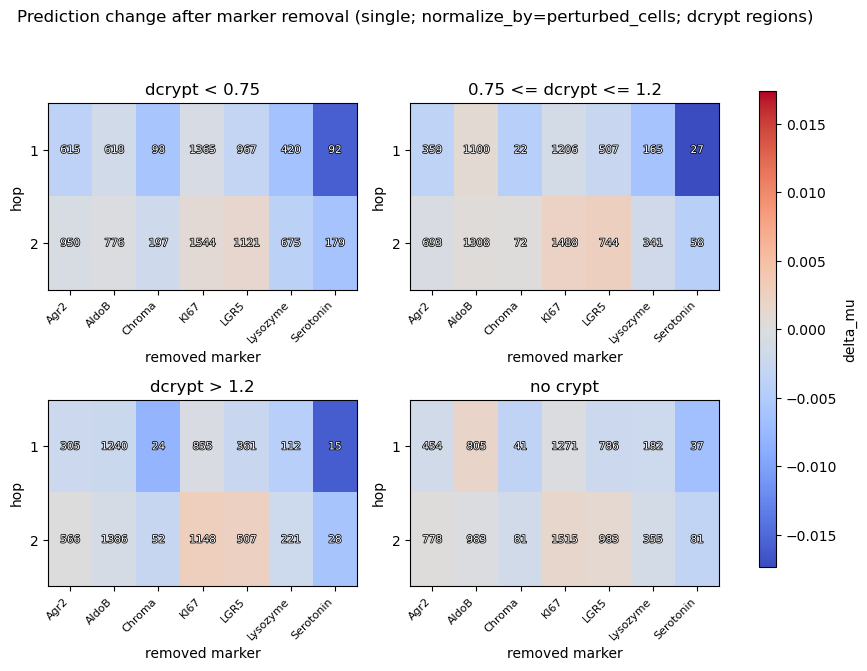

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_by_dcrypt_regions_hop_marker_single.pdf


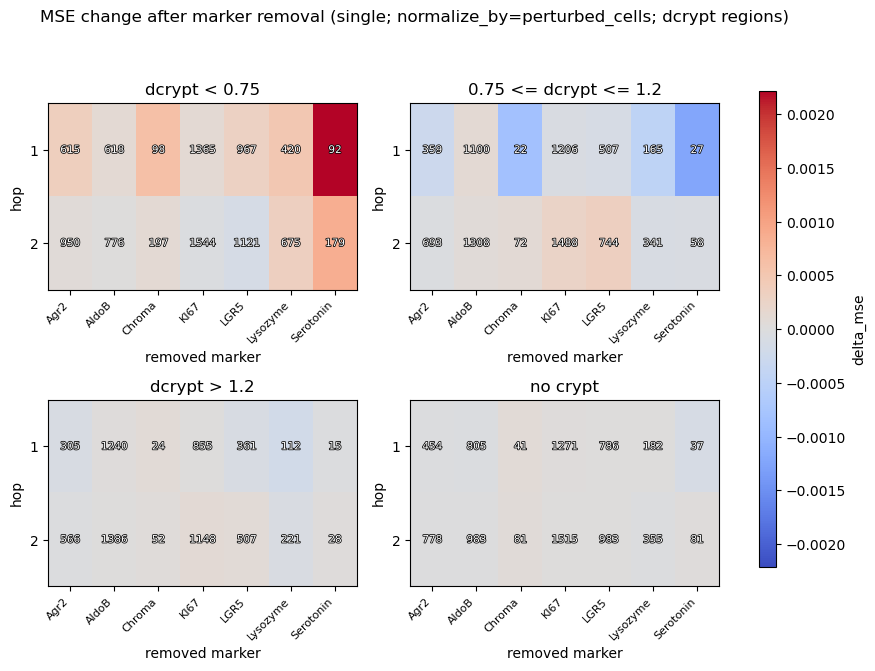

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_dcrypt_regions_marker_summary_single.pdf


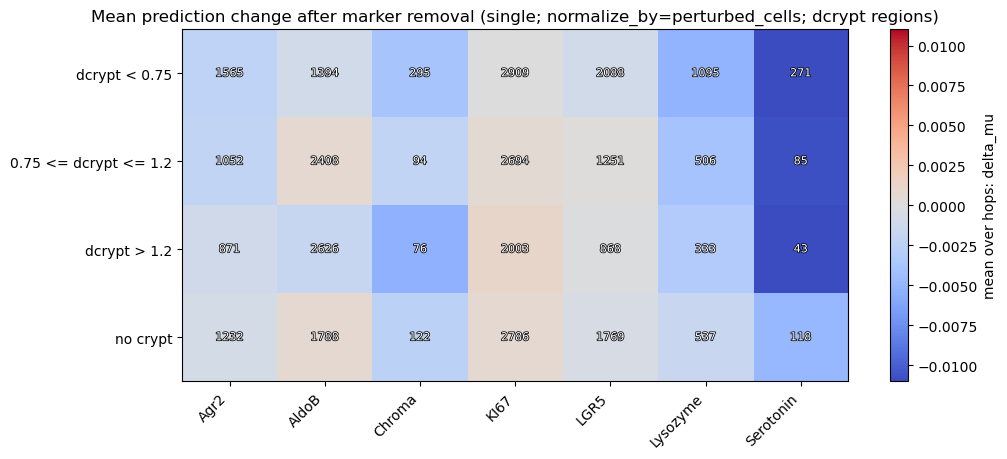

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_dcrypt_regions_marker_summary_single.pdf


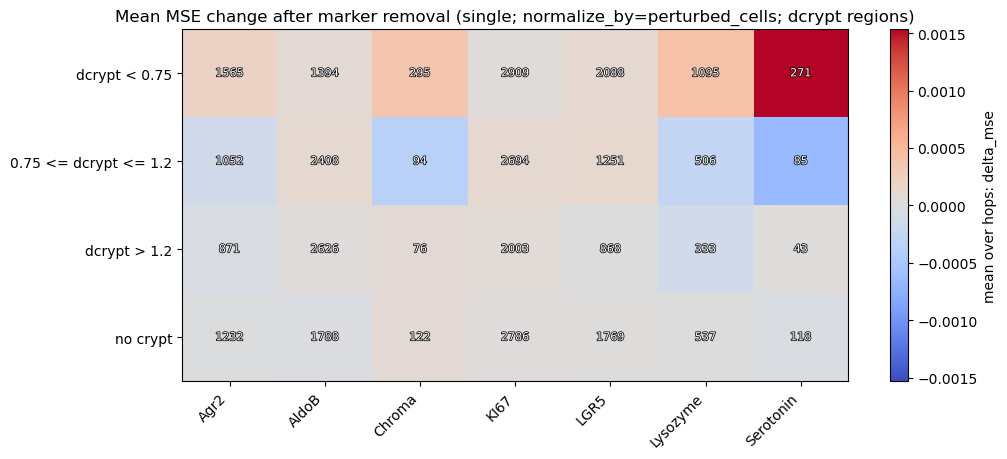

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_by_crypt_lgr5_domains_hop_marker_single.pdf


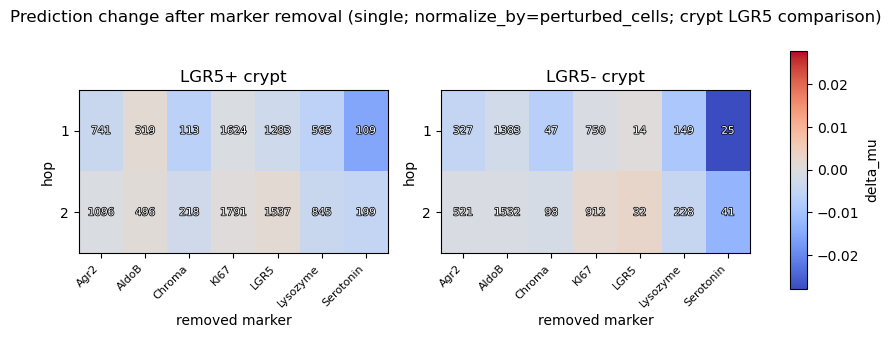

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_by_crypt_lgr5_domains_hop_marker_single.pdf


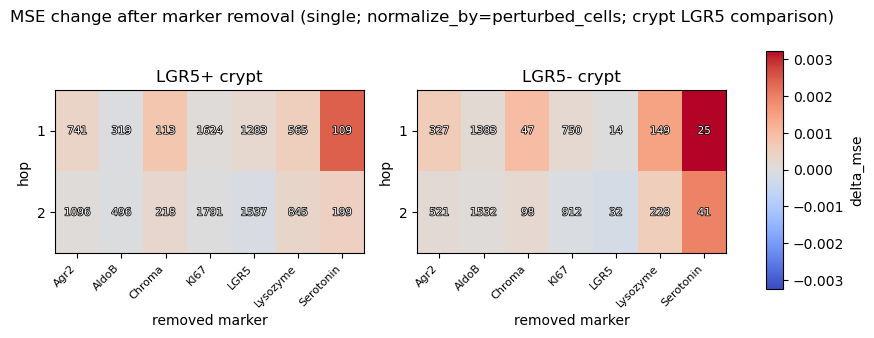

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_crypt_lgr5_domains_marker_summary_single.pdf


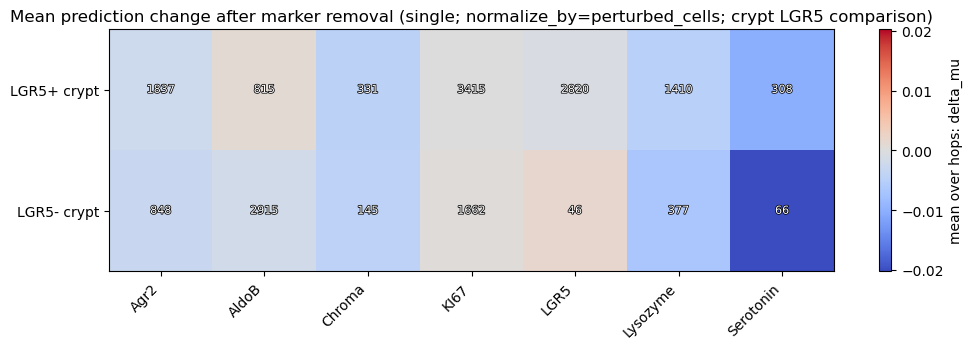

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_crypt_lgr5_domains_marker_summary_single.pdf


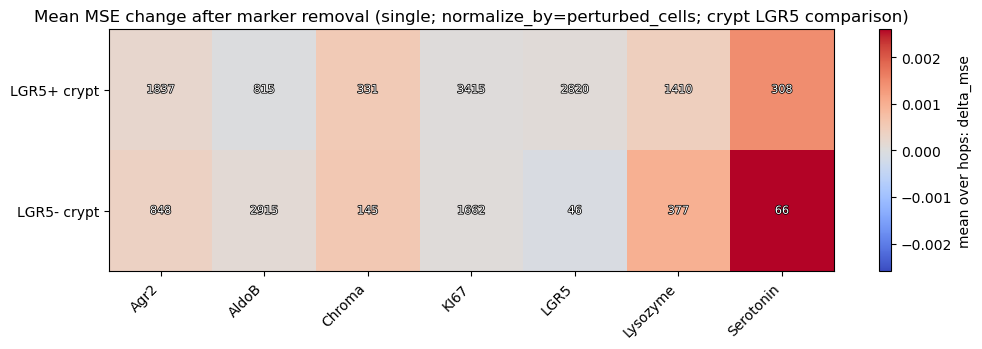

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_by_crypt_marker_removal_hop_marker_single.pdf


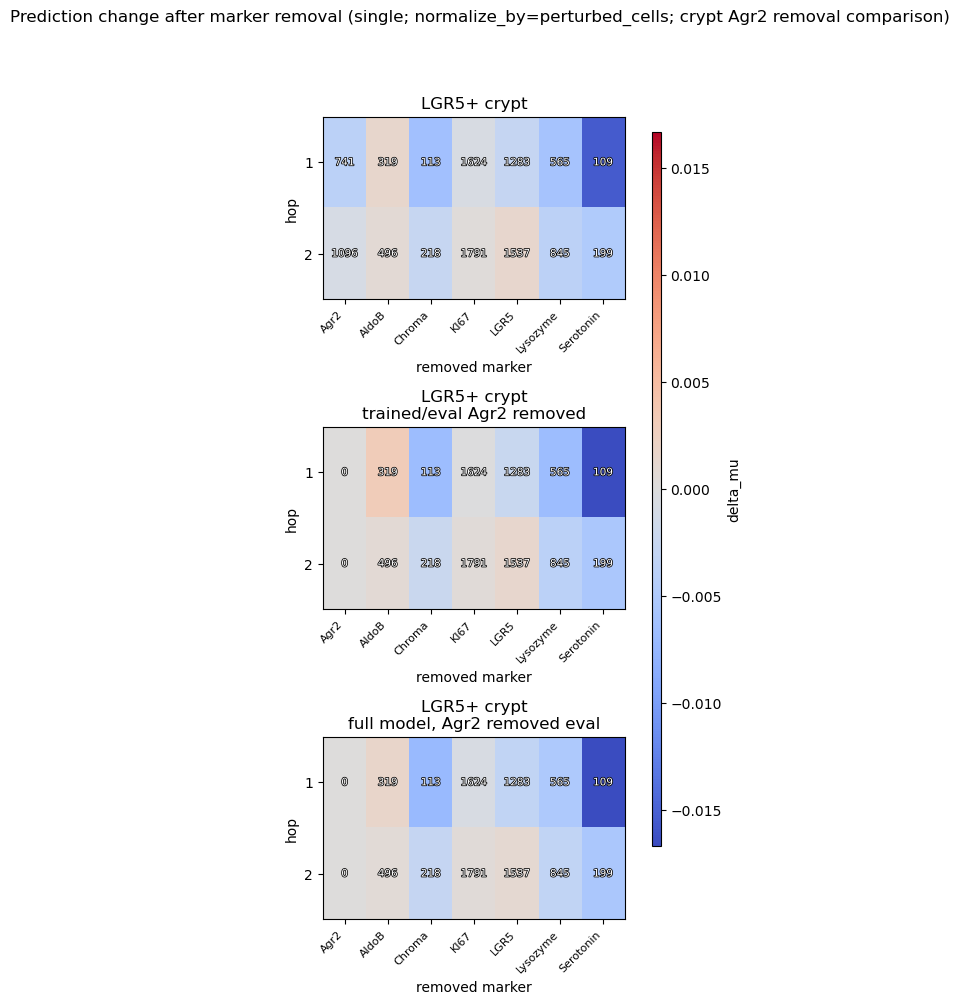

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_by_crypt_marker_removal_hop_marker_single.pdf


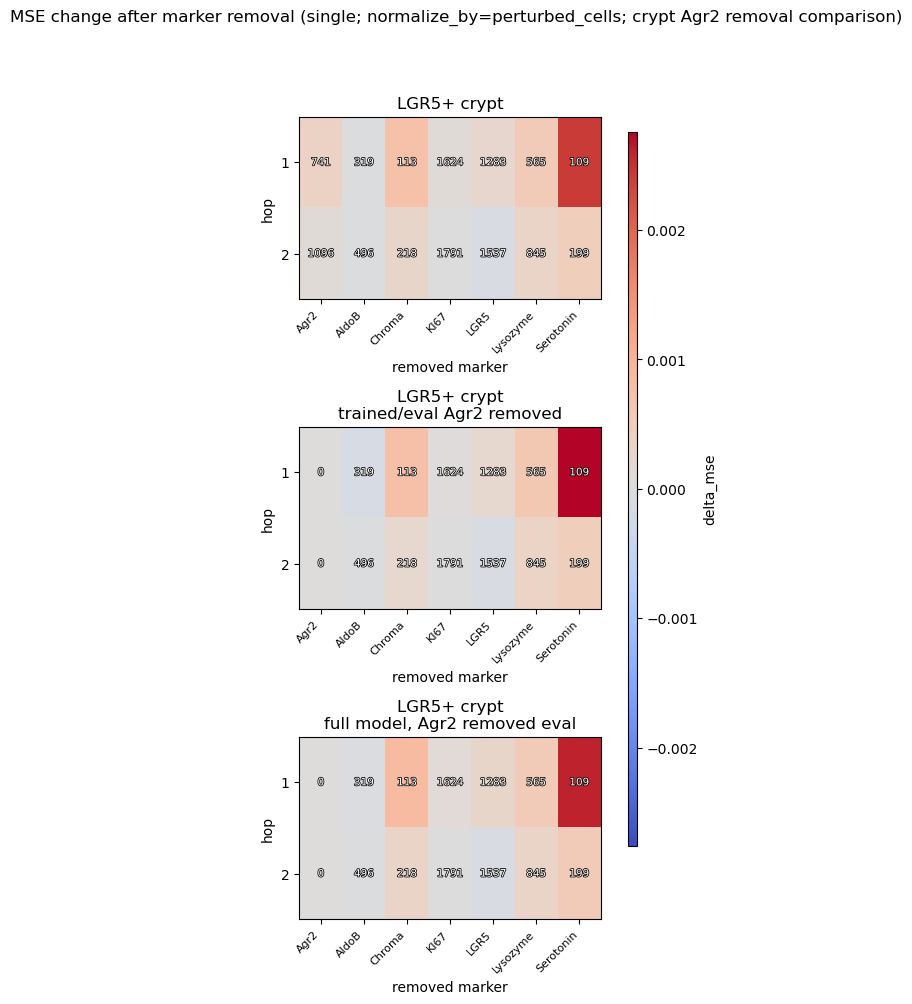

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_crypt_marker_removal_marker_summary_single.pdf


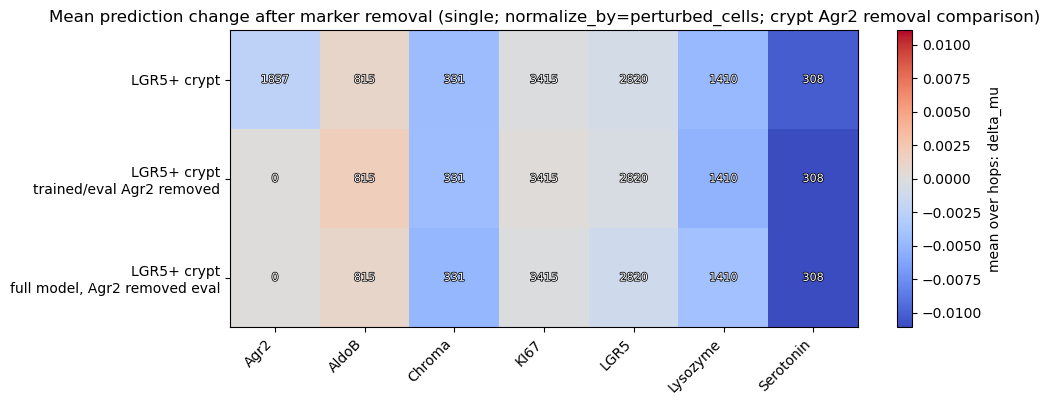

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_crypt_marker_removal_marker_summary_single.pdf


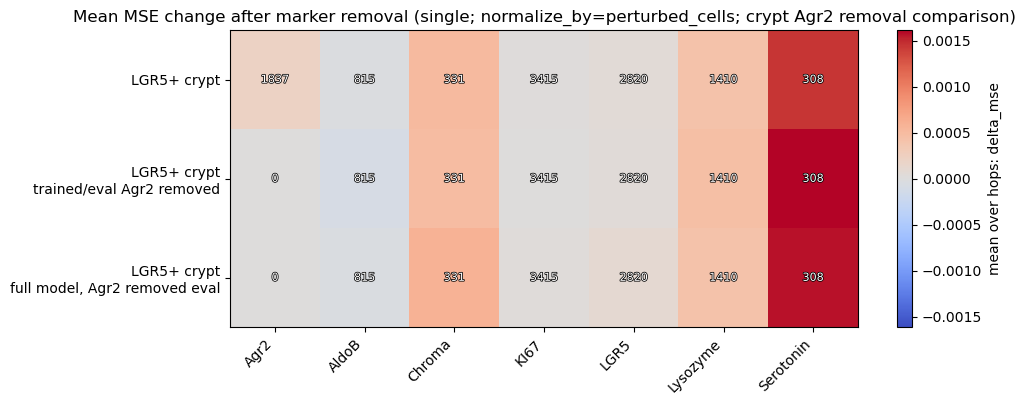

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_by_dcrypt_regions_hop_marker_all.pdf


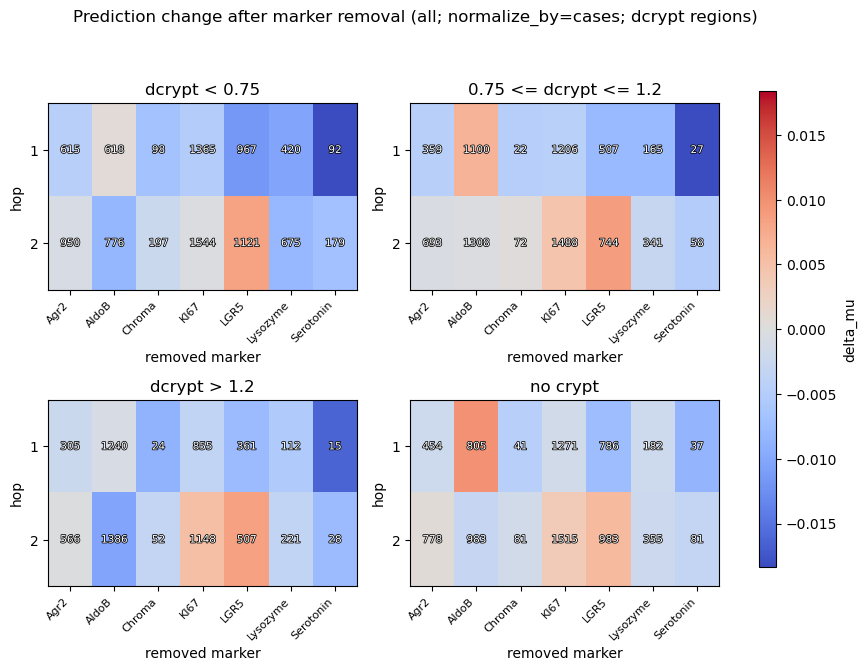

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_by_dcrypt_regions_hop_marker_all.pdf


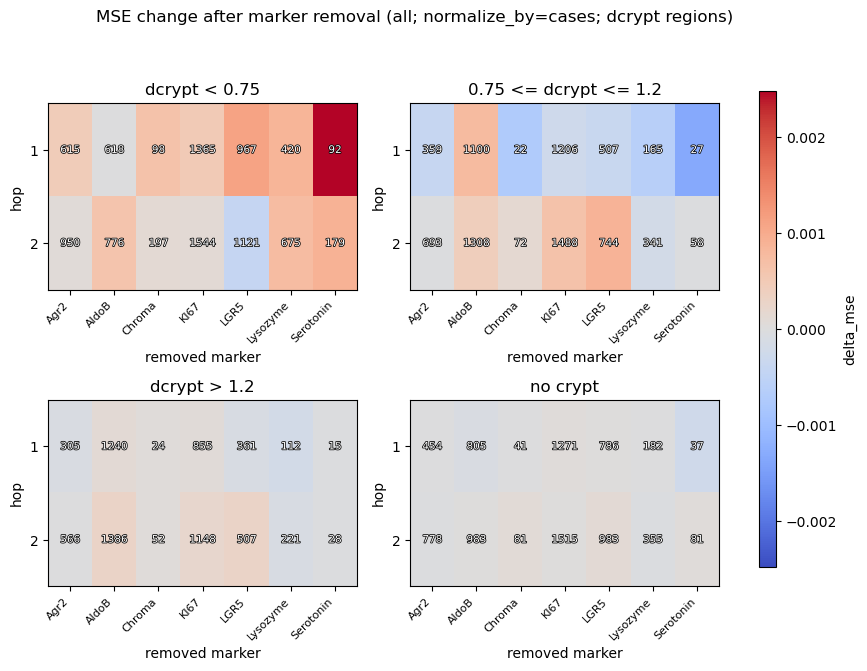

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_dcrypt_regions_marker_summary_all.pdf


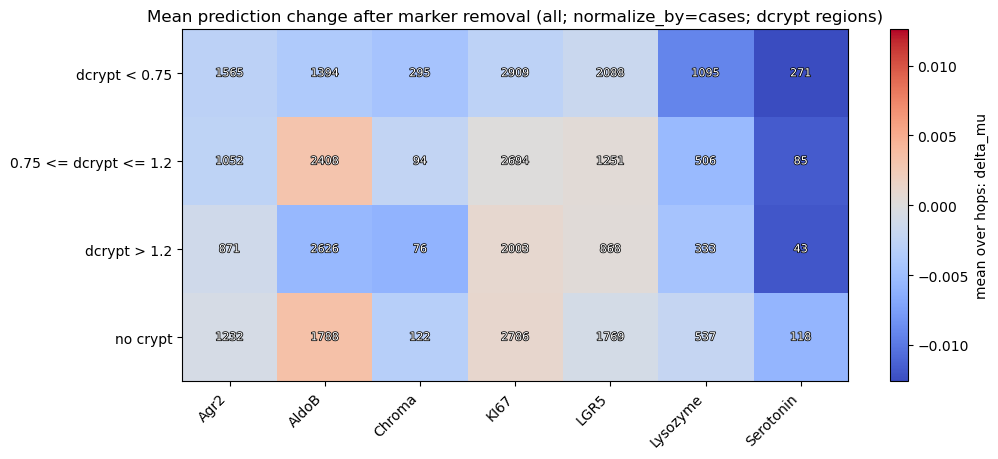

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_dcrypt_regions_marker_summary_all.pdf


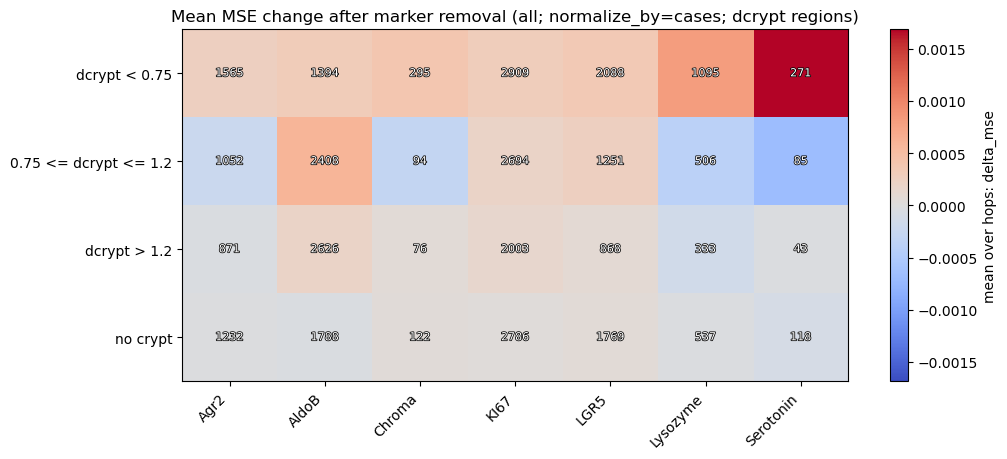

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_by_crypt_lgr5_domains_hop_marker_all.pdf


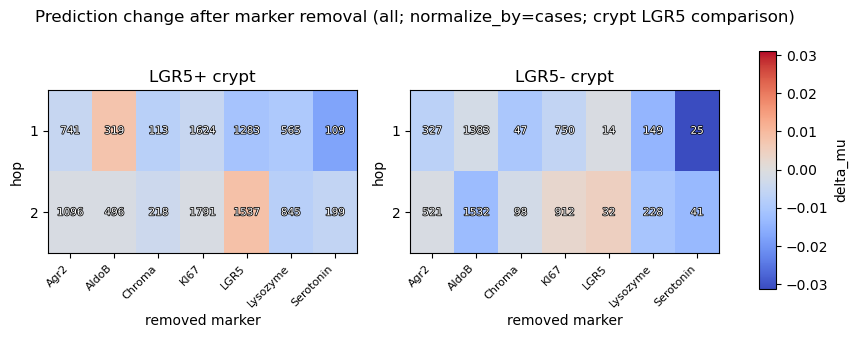

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_by_crypt_lgr5_domains_hop_marker_all.pdf


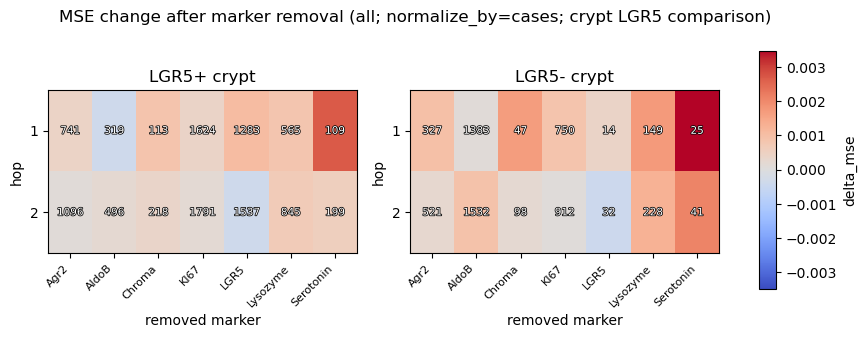

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_crypt_lgr5_domains_marker_summary_all.pdf


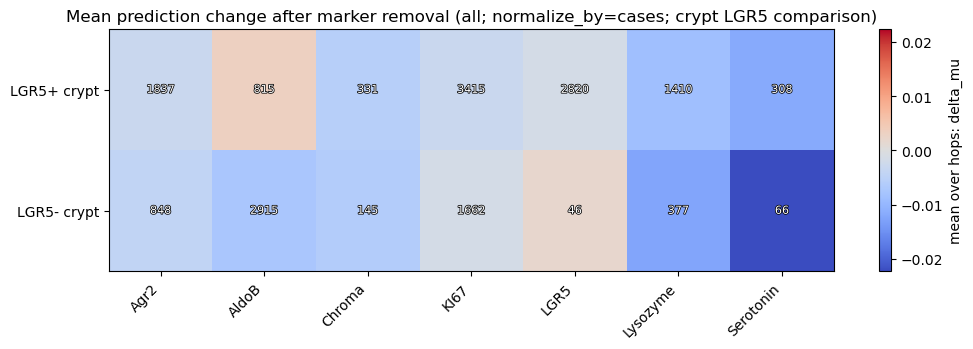

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_crypt_lgr5_domains_marker_summary_all.pdf


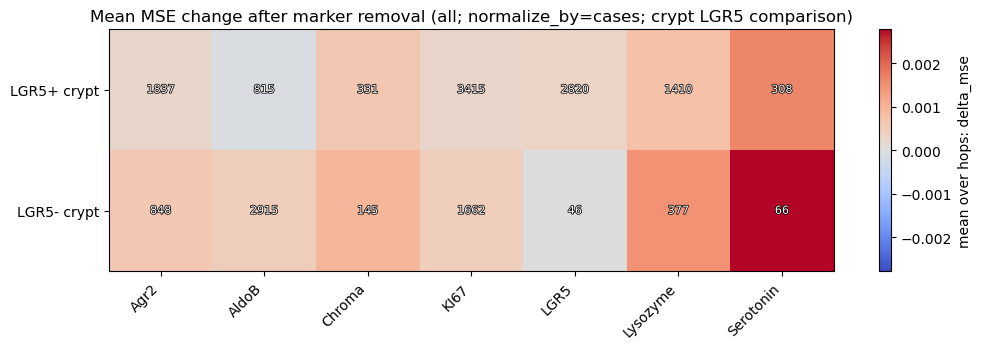

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_by_crypt_marker_removal_hop_marker_all.pdf


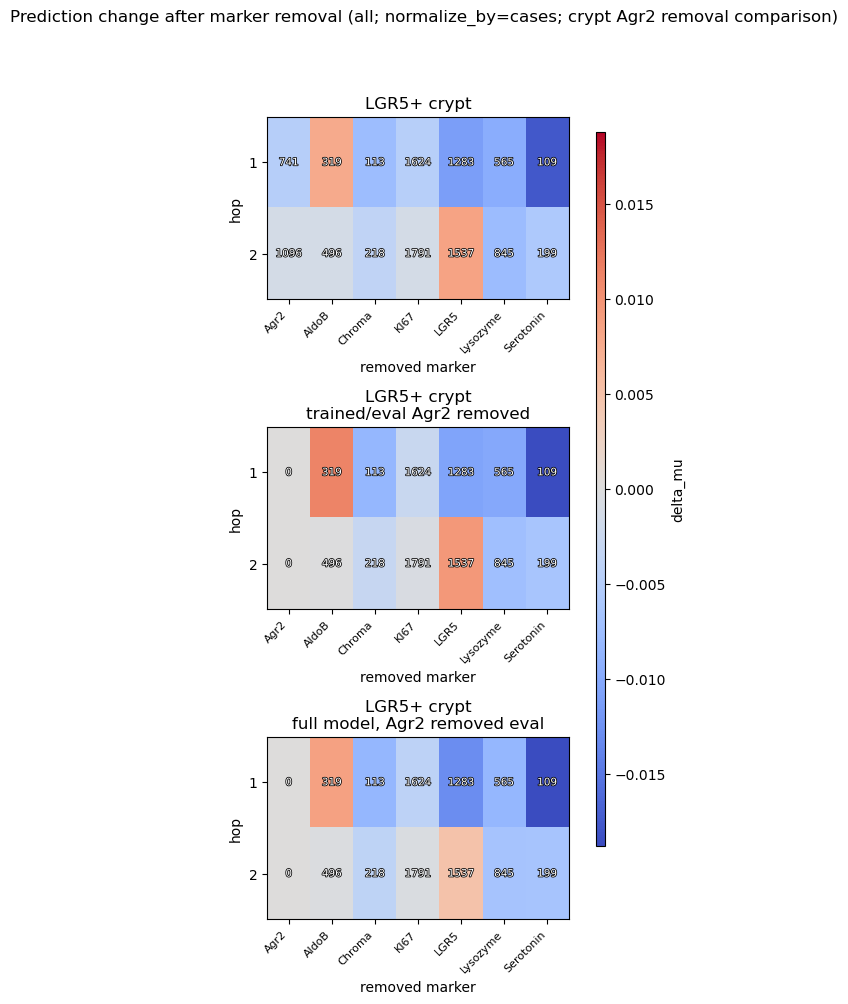

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_by_crypt_marker_removal_hop_marker_all.pdf


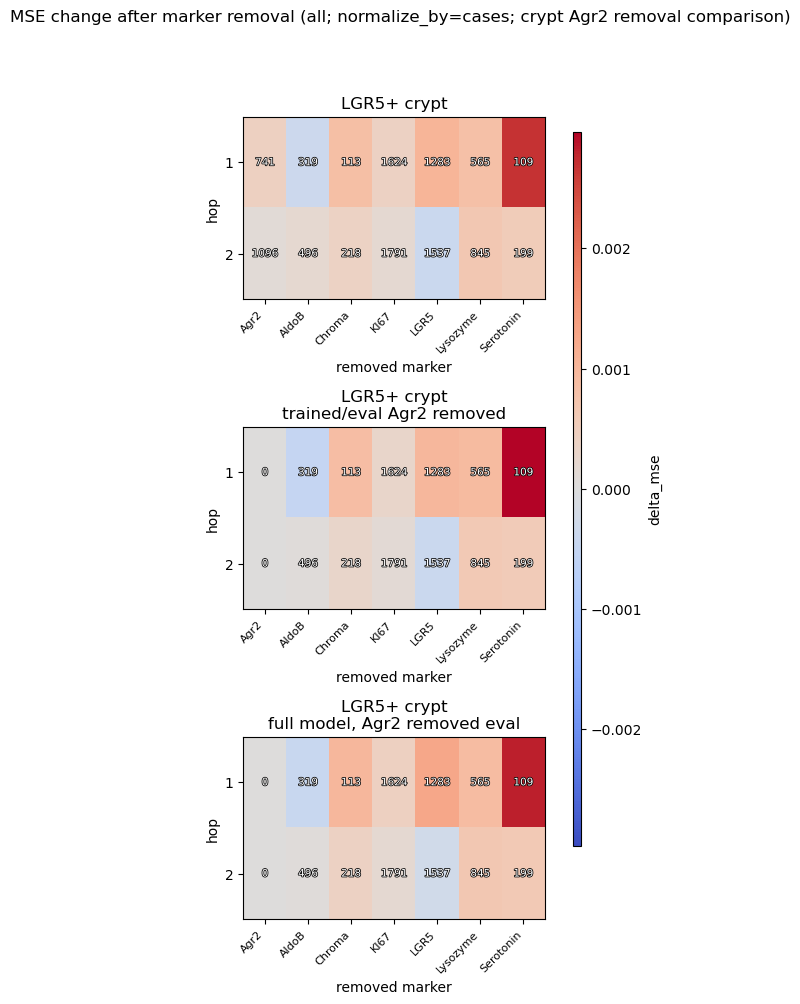

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mu_crypt_marker_removal_marker_summary_all.pdf


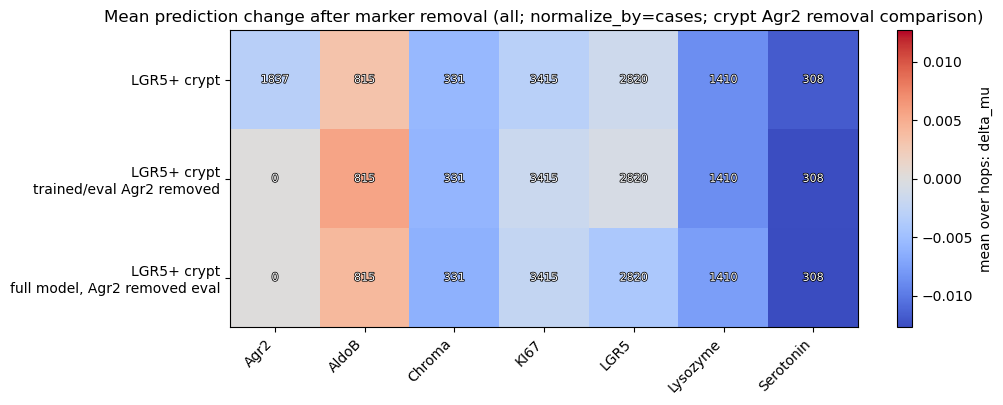

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145/figures/ablation_delta_mse_crypt_marker_removal_marker_summary_all.pdf


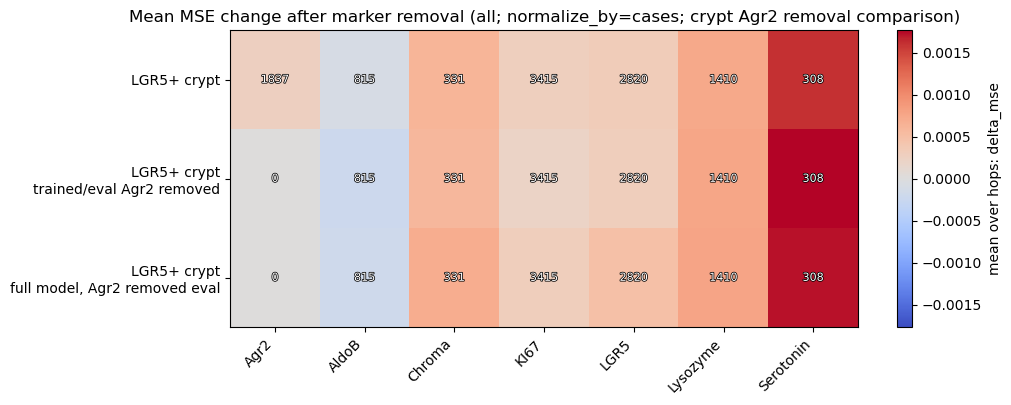

In [45]:
def ablation_annotation_col(mode):
    return "cases" if mode == "all" else "perturbed_cells"


def plot_ablation_hop_marker_panels(
    df,
    value_col,
    mode,
    title,
    filename,
    *,
    group_order,
    n_cols=2,
    cmap="coolwarm",
    center_zero=True,
):
    sub = df[(df["mode"] == mode) & (df["group"].isin(group_order))].copy()
    groups = [g for g in group_order if g in set(sub["group"])]
    n_rows = max(1, int(np.ceil(len(groups) / n_cols)))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows), squeeze=False)
    finite_values = sub[value_col].to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(finite_values)):
        vmax = np.nanmax(np.abs(finite_values))
        vmin = -vmax
    else:
        vmin = vmax = None

    count_col = ablation_annotation_col(mode)
    im = None
    for ax, group in zip(axes.ravel(), groups):
        group_df = sub[sub["group"] == group]
        table = (
            group_df
            .pivot(index="hop", columns="marker", values=value_col)
            .reindex(columns=marker_names)
            .sort_index()
        )
        annotation_table = (
            group_df
            .pivot(index="hop", columns="marker", values=count_col)
            .reindex(index=table.index, columns=table.columns)
        )
        im = ax.imshow(table.to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(DCRYPT_REGION_LABELS[group])
        ax.set_xlabel("removed marker")
        ax.set_ylabel("hop")
        ax.set_xticks(np.arange(len(marker_names)))
        ax.set_xticklabels(marker_names, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(table.index)))
        ax.set_yticklabels(table.index)
        annotate_heatmap_cells(ax, annotation_table, fontsize=7.5)
    for ax in axes.ravel()[len(groups):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.94])
    if im is not None:
        cax = fig.add_axes([0.91, 0.16, 0.02, 0.70])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(value_col)
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


def plot_ablation_region_marker_summary(
    df,
    value_col,
    mode,
    title,
    filename,
    *,
    group_order,
    cmap="coolwarm",
    center_zero=True,
):
    sub = df[(df["mode"] == mode) & (df["group"].isin(group_order))].copy()
    count_col = ablation_annotation_col(mode)
    summary = (
        sub.groupby(["group", "label", "marker"], as_index=False)
        .agg(
            value=(value_col, "mean"),
            annotation_count=(count_col, "sum"),
        )
    )
    table = summary.pivot(index="label", columns="marker", values="value")
    annotation_table = summary.pivot(index="label", columns="marker", values="annotation_count")
    row_labels = [DCRYPT_REGION_LABELS[g] for g in group_order if g in set(sub["group"])]
    table = table.reindex(row_labels)
    table = table.reindex(columns=marker_names)
    annotation_table = annotation_table.reindex(row_labels)
    annotation_table = annotation_table.reindex(columns=marker_names)

    values = table.to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(values)):
        vmax = np.nanmax(np.abs(values))
        vmin = -vmax
    else:
        vmin = vmax = None

    fig, ax = plt.subplots(figsize=(1.05 * len(marker_names) + 3, 0.55 * len(row_labels) + 2.5))
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(marker_names)))
    ax.set_xticklabels(marker_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    annotate_heatmap_cells(ax, annotation_table, fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"mean over hops: {value_col}")
    plt.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


ABLATION_ERROR_FIGURE_SPECS = [
    ("delta_mse", "MSE change", "delta_mse"),
    ("delta_mae", "MAE change", "delta_mae"),
    ("delta_relative_error", "Relative-error change to global baseline prediction", "delta_relative_error"),
]

for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, ABLATION_NORMALIZE_BY)
    mode_label = f"{mode}; normalize_by={normalize_by}"
    for group_order, suffix, title_prefix, n_cols in [
        (DCRYPT_REGION_ORDER, "dcrypt_regions", "dcrypt regions", 2),
        (CRYPT_COMPARISON_ORDER, "crypt_lgr5_domains", "crypt LGR5 comparison", 2),
        (CRYPT_MARKER_REMOVAL_COMPARISON_ORDER, "crypt_marker_removal", "crypt marker-removal comparison", 1),
    ]:
        plot_ablation_hop_marker_panels(
            ablation_df,
            "delta_mu",
            mode,
            f"Prediction change after marker removal ({mode_label}; {title_prefix})",
            f"ablation_delta_mu_by_{suffix}_hop_marker_{mode}",
            group_order=group_order,
            n_cols=n_cols,
        )
        plot_ablation_region_marker_summary(
            ablation_df,
            "delta_mu",
            mode,
            f"Mean prediction change after marker removal ({mode_label}; {title_prefix})",
            f"ablation_delta_mu_{suffix}_marker_summary_{mode}",
            group_order=group_order,
        )
        for value_col, metric_label, file_stem in ABLATION_ERROR_FIGURE_SPECS:
            plot_ablation_hop_marker_panels(
                ablation_df,
                value_col,
                mode,
                f"{metric_label} after marker removal ({mode_label}; {title_prefix})",
                f"ablation_{file_stem}_by_{suffix}_hop_marker_{mode}",
                group_order=group_order,
                n_cols=n_cols,
            )
            plot_ablation_region_marker_summary(
                ablation_df,
                value_col,
                mode,
                f"Mean {metric_label.lower()} after marker removal ({mode_label}; {title_prefix})",
                f"ablation_{file_stem}_{suffix}_marker_summary_{mode}",
                group_order=group_order,
            )


**Top Marker Tables**

These tables rank markers by their mean ablation effects, averaged over hop distances within each region.

In [46]:
def top_markers_by_group(df, value_col, mode, *, top_n=5, largest=True):
    sub = df[df["mode"] == mode].copy()
    summary = (
        sub.groupby(["group", "label", "marker"], as_index=False)
        .agg(value=(value_col, "mean"), cases=("cases", "sum"), perturbed_cells=("perturbed_cells", "sum"))
    )
    rows = []
    for group in [g for g in ANALYSIS_GROUP_ORDER if g in set(summary["group"])] :
        tmp = summary[summary["group"] == group].sort_values("value", ascending=not largest).head(top_n)
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, ABLATION_NORMALIZE_BY)
    print(f"Top markers by mean delta MSE | mode={mode} | normalize_by={normalize_by}")
    display_table(top_markers_by_group(ablation_df, "delta_mse", mode, top_n=5, largest=True))
    print(f"Top markers by mean delta MAE | mode={mode} | normalize_by={normalize_by}")
    display_table(top_markers_by_group(ablation_df, "delta_mae", mode, top_n=5, largest=True))
    print(f"Top markers by mean delta relative error | mode={mode} | normalize_by={normalize_by}")
    display_table(top_markers_by_group(ablation_df, "delta_relative_error", mode, top_n=5, largest=True))
    print(f"Most negative prediction changes | mode={mode} | normalize_by={normalize_by}")
    display_table(top_markers_by_group(ablation_df, "delta_mu", mode, top_n=5, largest=False))

Top markers by mean delta MSE | mode=single | normalize_by=perturbed_cells


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.75,Serotonin,0.001533,271,271
1,dcrypt < 0.75,Lysozyme,0.000419,1095,1095
2,dcrypt < 0.75,Chroma,0.000365,295,295
3,dcrypt < 0.75,Agr2,0.000203,1565,1565
4,dcrypt < 0.75,LGR5,0.000087,2088,2088
5,0.75 <= dcrypt <= 1.2,LGR5,0.000114,1251,1251
6,0.75 <= dcrypt <= 1.2,AldoB,0.000090,2408,2408
7,0.75 <= dcrypt <= 1.2,KI67,0.000088,2694,2694
8,0.75 <= dcrypt <= 1.2,Agr2,-0.000155,1052,1052
9,0.75 <= dcrypt <= 1.2,Lysozyme,-0.000270,506,506


Most negative prediction changes | mode=single | normalize_by=perturbed_cells


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.75,Serotonin,-0.010987,271,271
1,dcrypt < 0.75,Lysozyme,-0.005129,1095,1095
2,dcrypt < 0.75,Chroma,-0.003863,295,295
3,dcrypt < 0.75,Agr2,-0.002241,1565,1565
4,dcrypt < 0.75,AldoB,-0.000984,1394,1394
5,0.75 <= dcrypt <= 1.2,Serotonin,-0.010825,85,85
6,0.75 <= dcrypt <= 1.2,Lysozyme,-0.003956,506,506
7,0.75 <= dcrypt <= 1.2,Chroma,-0.002125,94,94
8,0.75 <= dcrypt <= 1.2,Agr2,-0.002040,1052,1052
9,0.75 <= dcrypt <= 1.2,LGR5,0.000076,1251,1251


Top markers by mean delta MSE | mode=all | normalize_by=cases


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.75,Serotonin,0.001685,271,334
1,dcrypt < 0.75,Lysozyme,0.000803,1095,2263
2,dcrypt < 0.75,Chroma,0.000384,295,415
3,dcrypt < 0.75,LGR5,0.000350,2088,11594
4,dcrypt < 0.75,AldoB,0.000308,1394,9567
5,0.75 <= dcrypt <= 1.2,AldoB,0.000587,2408,14498
6,0.75 <= dcrypt <= 1.2,LGR5,0.000259,1251,5325
7,0.75 <= dcrypt <= 1.2,KI67,0.000194,2694,12758
8,0.75 <= dcrypt <= 1.2,Agr2,-0.000217,1052,1744
9,0.75 <= dcrypt <= 1.2,Chroma,-0.000295,94,118


Most negative prediction changes | mode=all | normalize_by=cases


,label,marker,value,cases,perturbed_cells
0,dcrypt < 0.75,Serotonin,-0.012602,271,334
1,dcrypt < 0.75,Lysozyme,-0.009243,1095,2263
2,dcrypt < 0.75,Chroma,-0.004527,295,415
3,dcrypt < 0.75,AldoB,-0.003788,1394,9567
4,dcrypt < 0.75,Agr2,-0.002763,1565,2823
5,0.75 <= dcrypt <= 1.2,Serotonin,-0.011677,85,106
6,0.75 <= dcrypt <= 1.2,Lysozyme,-0.005358,506,872
7,0.75 <= dcrypt <= 1.2,Agr2,-0.002654,1052,1744
8,0.75 <= dcrypt <= 1.2,Chroma,-0.002287,94,118
9,0.75 <= dcrypt <= 1.2,KI67,0.000062,2694,12758


**Crypt-Only Tables**

These compact tables repeat the key outputs for the crypt-domain splits, including LGR5-present/absent categories and whole-organoid crypt-marker removal contexts.


In [47]:
# Compact crypt-only comparison tables for the requested LGR5-domain split.
crypt_compare_groups = CRYPT_COMPARISON_ORDER
crypt_baseline_df = baseline_region_df[baseline_region_df["group"].isin(crypt_compare_groups)].copy()
crypt_marker_count_df = marker_count_region_df[marker_count_region_df["group"].isin(crypt_compare_groups)].copy()
crypt_ablation_df = ablation_df[ablation_df["group"].isin(crypt_compare_groups)].copy()

display_table(crypt_baseline_df)
display_table(crypt_marker_count_df, head=16)
display_table(crypt_ablation_df, head=16)
# Compact crypt-only comparison tables for the whole-organoid crypt-marker removal analysis.
crypt_marker_removal_compare_groups = CRYPT_MARKER_REMOVAL_COMPARISON_ORDER
crypt_marker_removal_baseline_df = baseline_region_df[baseline_region_df["group"].isin(crypt_marker_removal_compare_groups)].copy()
crypt_marker_removal_marker_count_df = marker_count_region_df[marker_count_region_df["group"].isin(crypt_marker_removal_compare_groups)].copy()
crypt_marker_removal_ablation_df = ablation_df[ablation_df["group"].isin(crypt_marker_removal_compare_groups)].copy()

display_table(crypt_marker_removal_baseline_df)
display_table(crypt_marker_removal_marker_count_df, head=16)
display_table(crypt_marker_removal_ablation_df, head=16)


,label,model_context,n_nodes,mse,sem_mse,mse_global_baseline,sem_mse_global_baseline,mse_gin_depth0,sem_mse_gin_depth0,pred_var_mean,sem_pred_var,spearman_pred_var_sqerr
4,LGR5+ crypt,full,16685,0.004336,0.000060,0.006704,0.000082,0.005515,0.000072,0.002791,0.000020,0.228407
5,LGR5- crypt,full,6253,0.003891,0.000102,0.004522,0.000119,0.005122,0.000125,0.001572,0.000031,0.414296


,label,model_context,marker,marker_index,n_nodes,n_marker_positive,mean_count_within_rf,fraction_with_marker_visible,spearman_count_true,spearman_count_pred,spearman_count_sqerr,spearman_count_pred_var
28,LGR5+ crypt,full,Agr2,0,16685,1523,1.676716,0.673180,0.193161,0.412756,-0.020779,0.096600
29,LGR5+ crypt,full,AldoB,1,16685,1615,2.163021,0.254180,-0.102201,-0.207458,0.020720,-0.158098
30,LGR5+ crypt,full,Chroma,2,16685,233,0.247048,0.135151,0.129998,0.238312,0.040377,0.100586
31,LGR5+ crypt,full,KI67,3,16685,8584,9.973749,0.910878,-0.040734,0.093322,-0.102593,0.005548
32,LGR5+ crypt,full,LGR5,4,16685,7533,8.348696,0.778244,0.262178,0.529028,0.008931,0.035198
33,LGR5+ crypt,full,Lysozyme,5,16685,1382,1.462331,0.473239,0.281044,0.589421,0.019833,0.230929
34,LGR5+ crypt,full,Serotonin,6,16685,203,0.212766,0.139766,0.185473,0.314595,0.074280,0.156323
35,LGR5- crypt,full,Agr2,0,6253,297,0.850792,0.313450,0.296217,0.246749,0.243072,0.486964
36,LGR5- crypt,full,AldoB,1,6253,3771,12.020630,0.764753,-0.317774,-0.205221,-0.321708,-0.575799
37,LGR5- crypt,full,Chroma,2,6253,40,0.109707,0.060131,0.116487,0.152934,0.080847,0.254004


,label,mode,normalize_by,model_context,hop,marker,marker_index,delta_mu,abs_delta_mu,delta_mse,abs_delta_mse,cases,perturbed_cells
112,LGR5+ crypt,single,perturbed_cells,full,1,Agr2,0,-0.003845,0.005131,0.000356,0.000601,741,741
113,LGR5+ crypt,single,perturbed_cells,full,1,AldoB,1,0.001497,0.005533,-0.000040,0.000602,319,319
114,LGR5+ crypt,single,perturbed_cells,full,1,Chroma,2,-0.006356,0.007896,0.000740,0.001109,113,113
115,LGR5+ crypt,single,perturbed_cells,full,1,KI67,3,-0.000653,0.003249,0.000065,0.000356,1624,1624
116,LGR5+ crypt,single,perturbed_cells,full,1,LGR5,4,-0.002857,0.003933,0.000229,0.000446,1283,1283
117,LGR5+ crypt,single,perturbed_cells,full,1,Lysozyme,5,-0.005892,0.006378,0.000528,0.000730,565,565
118,LGR5+ crypt,single,perturbed_cells,full,1,Serotonin,6,-0.015400,0.015822,0.002426,0.002859,109,109
119,LGR5+ crypt,single,perturbed_cells,full,2,Agr2,0,-0.000850,0.002055,0.000070,0.000215,1096,1096
120,LGR5+ crypt,single,perturbed_cells,full,2,AldoB,1,0.000687,0.002723,-0.000033,0.000282,496,496
121,LGR5+ crypt,single,perturbed_cells,full,2,Chroma,2,-0.002727,0.003371,0.000276,0.000400,218,218


,label,model_context,n_nodes,mse,sem_mse,mse_global_baseline,sem_mse_global_baseline,mse_gin_depth0,sem_mse_gin_depth0,pred_var_mean,sem_pred_var,spearman_pred_var_sqerr
4,LGR5+ crypt,full,16685,0.004336,0.000060,0.006704,0.000082,0.005515,0.000072,0.002791,0.000020,0.228407
6,LGR5+ crypt\ntrained/eval Agr2 removed,crypt_markers_removed,16685,0.004292,0.000059,0.006704,0.000082,0.005545,0.000072,0.002827,0.000022,0.230009
7,"LGR5+ crypt\nfull model, Agr2 removed eval",full_eval_crypt_markers_removed,16685,0.004610,0.000062,0.006704,0.000082,0.005545,0.000072,0.002566,0.000019,0.254436


,label,model_context,marker,marker_index,n_nodes,n_marker_positive,mean_count_within_rf,fraction_with_marker_visible,spearman_count_true,spearman_count_pred,spearman_count_sqerr,spearman_count_pred_var
28,LGR5+ crypt,full,Agr2,0,16685,1523,1.676716,0.673180,0.193161,0.412756,-0.020779,0.096600
29,LGR5+ crypt,full,AldoB,1,16685,1615,2.163021,0.254180,-0.102201,-0.207458,0.020720,-0.158098
30,LGR5+ crypt,full,Chroma,2,16685,233,0.247048,0.135151,0.129998,0.238312,0.040377,0.100586
31,LGR5+ crypt,full,KI67,3,16685,8584,9.973749,0.910878,-0.040734,0.093322,-0.102593,0.005548
32,LGR5+ crypt,full,LGR5,4,16685,7533,8.348696,0.778244,0.262178,0.529028,0.008931,0.035198
33,LGR5+ crypt,full,Lysozyme,5,16685,1382,1.462331,0.473239,0.281044,0.589421,0.019833,0.230929
34,LGR5+ crypt,full,Serotonin,6,16685,203,0.212766,0.139766,0.185473,0.314595,0.074280,0.156323
42,LGR5+ crypt\ntrained/eval Agr2 removed,crypt_markers_removed,Agr2,0,16685,0,0.000000,0.000000,NaN,NaN,NaN,NaN
43,LGR5+ crypt\ntrained/eval Agr2 removed,crypt_markers_removed,AldoB,1,16685,1615,2.163021,0.254180,-0.102201,-0.212803,0.023820,-0.138891
44,LGR5+ crypt\ntrained/eval Agr2 removed,crypt_markers_removed,Chroma,2,16685,233,0.247048,0.135151,0.129998,0.248518,0.032963,0.088151


,label,mode,normalize_by,model_context,hop,marker,marker_index,delta_mu,abs_delta_mu,delta_mse,abs_delta_mse,cases,perturbed_cells
112,LGR5+ crypt,single,perturbed_cells,full,1,Agr2,0,-0.003845,0.005131,0.000356,0.000601,741,741
113,LGR5+ crypt,single,perturbed_cells,full,1,AldoB,1,0.001497,0.005533,-0.000040,0.000602,319,319
114,LGR5+ crypt,single,perturbed_cells,full,1,Chroma,2,-0.006356,0.007896,0.000740,0.001109,113,113
115,LGR5+ crypt,single,perturbed_cells,full,1,KI67,3,-0.000653,0.003249,0.000065,0.000356,1624,1624
116,LGR5+ crypt,single,perturbed_cells,full,1,LGR5,4,-0.002857,0.003933,0.000229,0.000446,1283,1283
117,LGR5+ crypt,single,perturbed_cells,full,1,Lysozyme,5,-0.005892,0.006378,0.000528,0.000730,565,565
118,LGR5+ crypt,single,perturbed_cells,full,1,Serotonin,6,-0.015400,0.015822,0.002426,0.002859,109,109
119,LGR5+ crypt,single,perturbed_cells,full,2,Agr2,0,-0.000850,0.002055,0.000070,0.000215,1096,1096
120,LGR5+ crypt,single,perturbed_cells,full,2,AldoB,1,0.000687,0.002723,-0.000033,0.000282,496,496
121,LGR5+ crypt,single,perturbed_cells,full,2,Chroma,2,-0.002727,0.003371,0.000276,0.000400,218,218


**Save Results**

Save the configuration, result tables, figures, and training metadata for the experiment run.

In [48]:
def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_experiment(save_dir, config, results, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    dcrypt_region_count_df.to_csv(save_dir / "dcrypt_region_node_counts.csv", index=False)
    analysis_group_count_df.to_csv(save_dir / "analysis_group_node_counts.csv", index=False)
    baseline_region_df.to_csv(save_dir / "baseline_region_metrics.csv", index=False)
    marker_count_region_df.to_csv(save_dir / "local_marker_count_region_metrics.csv", index=False)
    true_curvature_marker_region_df.to_csv(save_dir / "true_curvature_by_region_marker.csv", index=False)
    ablation_df.to_csv(save_dir / "region_marker_ablation_metrics.csv", index=False)
    group_subgraph_info.to_csv(save_dir / "group_subgraph_counts.csv", index=False)
    crypt_marker_removal_baseline_df.to_csv(save_dir / "crypt_marker_removal_baseline_metrics.csv", index=False)
    crypt_marker_removal_marker_count_df.to_csv(save_dir / "crypt_marker_removal_marker_count_metrics.csv", index=False)
    crypt_marker_removal_ablation_df.to_csv(save_dir / "crypt_marker_removal_ablation_metrics.csv", index=False)
    removal_prediction_summary_df.to_csv(save_dir / "marker_removal_prediction_summary.csv", index=False)
    print(f"Saved experiment -> {save_dir}")


experiment_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_plots": TARGET_INDEX_FOR_PLOTS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    "target_transform": target_transform.name,
    "dcrypt_field": DCRYPT_FIELD,
    "dcrypt_region_order": DCRYPT_REGION_ORDER,
    "crypt_comparison_order": CRYPT_COMPARISON_ORDER,
    "crypt_marker_removal_comparison_order": CRYPT_MARKER_REMOVAL_COMPARISON_ORDER,
    "lgr5_marker_name": LGR5_MARKER_NAME,
    "removal_sets": REMOVAL_SETS,
    "model_context_by_group": MODEL_CONTEXT_BY_GROUP,
    "control_models": {
        "global_baseline": "GlobalFeatureMLP using global_feat only",
        "gin_depth0": "GINCurvature with num_layers=0 using center marker features and global_feat",
    },
    "model": {
        "class": MODEL_CLASS,
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "ablation": {
        "modes": ABLATION_MODES,
        "normalize_by": ABLATION_NORMALIZE_BY,
        "normalize_by_by_mode": ABLATION_NORMALIZE_BY_BY_MODE,
        "max_subgraphs_per_group": MAX_SUBGRAPHS_PER_GROUP,
        "min_group_nodes": MIN_GROUP_NODES,
        "batch_size": PERTURBATION_BATCH_SIZE,
    },
    "local_count_hops": LOCAL_COUNT_HOPS,
    "relative_error_eps": RELATIVE_ERROR_EPS,
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
    },
    "filters": {
        "blacklist_n_keys": len(blacklist),
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "marker_names": list(marker_names),
    "field_specs": field_specs,
    "figures_dir": str(FIGURES_DIR),
}

experiment_results = {
    "dcrypt_region_count_df": dcrypt_region_count_df,
    "analysis_group_count_df": analysis_group_count_df,
    "baseline_region_df": baseline_region_df,
    "marker_count_region_df": marker_count_region_df,
    "true_curvature_marker_region_df": true_curvature_marker_region_df,
    "ablation_df": ablation_df,
    "group_subgraph_info": group_subgraph_info,
    "crypt_baseline_df": crypt_baseline_df,
    "crypt_marker_count_df": crypt_marker_count_df,
    "crypt_ablation_df": crypt_ablation_df,
    "crypt_marker_removal_baseline_df": crypt_marker_removal_baseline_df,
    "crypt_marker_removal_marker_count_df": crypt_marker_removal_marker_count_df,
    "crypt_marker_removal_ablation_df": crypt_marker_removal_ablation_df,
    "removal_prediction_summary_df": removal_prediction_summary_df,
    "training_log": training_log,
    "global_baseline_training_log": global_baseline_training_log,
    "gin_depth0_baseline_training_log": gin_depth0_baseline_training_log,
    "removal_training_logs": removal_training_logs,
    "split_info": split_info,
    "outlier_info": outlier_info,
}

save_experiment(
    SAVE_DIR,
    experiment_config,
    experiment_results,
    notes="dcrypt-region marker informativeness analysis with baseline metrics, ablation, local RF marker counts, LGR5 crypt-domain comparison, and marker-removal contexts.",
)


Saved experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/dcrypt_region_marker_informativeness/run_20260527_120145
